# 2 Descriptive (Spatial) Analytics

Section 1 covered *what is in the data*, this section asks *what does the data tell us*. We use descriptive and exploratory methods to characterize Chicago taxi demand, but no predictive modeling yet, that's Section 3. The goal is to surface structure, find spatial hot spots, and build an empirical picture of demand that the modeling in Section 3 and the recommendations in Section 5 can build on.

Guiding questions:
1. How does demand vary over time (hour, weekday, month, season)?
2. How does demand vary over space, and where are the natural hot spots?
3. How do time and space interact?
4. Where do trips actually go and what are the dominant origin-destination flows?
5. Which external factors (mainly weather) move demand, and how strongly?
6. How do trip characteristics (length, price, idle time) differ by region?
7. How sensitive are these patterns to the chosen spatial/temporal resolution?

These map onto the three consulting layers from Section 1: **strategic** (where to enter the market), **tactical** (when/how many vehicles to deploy), and **operational** (idle time, repositioning, charging).

- *2.1 Temporal Patterns*
- *2.2 Spatial Patterns and Hotspot Identification*
- *2.3 Spatio-Temporal Interplay*
- *2.4 Origin-Destination Flows*
- *2.5 External Drivers: Weather*
- *2.6 Spatial Variation in Trip Characteristics*
- *2.7 Resolution Sensitivity*
- *2.8 Summary and Implications*

2.1-2.3 build up in order: time alone, space alone, then their interaction, so each effect is readable before we combine them. 2.4-2.6 add three more dimensions (destinations, weather, per-area trip differences). 2.7 is the resolution check the brief explicitly asks for, and 2.8 pulls everything into strategic/tactical/operational recommendations. Each subsection closes with a short takeaway tying the pattern back to a likely cause.

**A note on spatial units:** the canonical grid throughout this chapter is **H3 resolution 6** (the resolution chosen in Task 1). Community Areas are used in parallel wherever a human-readable administrative unit is more useful.

## Setup and data loading

In [ ]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

BLUES_DARK = LinearSegmentedColormap.from_list(
    "BluesDark", plt.cm.Blues(np.linspace(0.1, 1.0, 256))
)

PROCESSED = pathlib.Path("../processed")

def _load(name):
    return pd.read_parquet(PROCESSED / f"{name}.parquet")

# Small aggregates (all tiny)
agg_city_dow_hour  = _load("agg_city_dow_hour")    # (day_of_week, hour) -> n_trips, mean_trip_*
agg_city_month     = _load("agg_city_month")       # (month_start) -> n_trips
idle_city_dow_hour = _load("idle_city_dow_hour")   # (day_of_week, hour) -> mean_idle_secs, n
agg_h3r4_total     = _load("agg_h3r4_total")       # (h3_r4) -> n_trips
agg_h3r5_total     = _load("agg_h3r5_total")       # (h3_r5) -> n_trips
agg_h3r6_total     = _load("agg_h3r6_total")       # (h3_r6) -> n_trips
agg_h3r7_total     = _load("agg_h3r7_total")       # (h3_r7) -> n_trips
agg_h3r8_total     = _load("agg_h3r8_total")       # (h3_r8) -> n_trips
agg_ca_total       = _load("agg_ca_total")         # (pickup_community_area) -> n_trips
agg_h3r6_dow_hour  = _load("agg_h3r6_dow_hour")    # (h3_r6, day_of_week, hour) -> n_trips
agg_h3r6_dow_hour["n_trips"] = agg_h3r6_dow_hour["n_trips"].astype("int64")
calendar_counts    = _load("calendar_counts")      # (day_of_week) -> n_dates

TOTAL_DATES = int(calendar_counts["n_dates"].sum())
N_DATES = calendar_counts.set_index("day_of_week")["n_dates"].to_dict()  # dow -> days
WEEKDAYS, WEEKEND = [0, 1, 2, 3, 4], [5, 6]
DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print(f"Total distinct dates in sample: {TOTAL_DATES}")
print("Days per weekday:", N_DATES)
print("Active H3 cells — r4:", len(agg_h3r4_total),
      "| r5:", len(agg_h3r5_total), "| r6:", len(agg_h3r6_total), "| r7:", len(agg_h3r7_total), "| r8:", len(agg_h3r8_total))


Total distinct dates in sample: 822
Days per weekday: {0: 118, 1: 118, 2: 118, 3: 117, 4: 117, 5: 117, 6: 117}
Active H3 cells — r4: 4 | r5: 8 | r6: 27 | r7: 128 | r8: 475


In [3]:
import h3

# demand-per-day helpers (city level)
def city_hourly_mean(dows):
    """Mean pickups per hour-of-day across the given weekdays (averaged over days)."""
    sub = agg_city_dow_hour[agg_city_dow_hour["day_of_week"].isin(dows)]
    n_days = sum(N_DATES[d] for d in dows)
    return (sub.groupby("hour")["n_trips"].sum() / n_days).reindex(range(24), fill_value=0)

def city_charac_hourly(col, dows):
    """Trip-count-weighted mean of a characteristic by hour-of-day for given weekdays."""
    sub = agg_city_dow_hour[agg_city_dow_hour["day_of_week"].isin(dows)].copy()
    sub["_w"] = sub[col] * sub["n_trips"]
    g = sub.groupby("hour").agg(w=("_w", "sum"), n=("n_trips", "sum"))
    return (g["w"] / g["n"]).reindex(range(24))

def idle_hourly(dows):
    """Trip-count-weighted mean idle seconds by hour-of-day for given weekdays."""
    sub = idle_city_dow_hour[idle_city_dow_hour["day_of_week"].isin(dows)].copy()
    sub["_w"] = sub["mean_idle_secs"] * sub["n"]
    g = sub.groupby("hour").agg(w=("_w", "sum"), n=("n", "sum"))
    return (g["w"] / g["n"]).reindex(range(24))

# H3 polygon helpers (h3 v4: cell_to_boundary returns (lat, lng) pairs)
def hex_polygon_xy(cell):
    """Return [(lng, lat), ...] for a hex, handling antimeridian-free Chicago case."""
    return [(lng, lat) for (lat, lng) in h3.cell_to_boundary(cell)]

def draw_hex_choropleth(ax, cell_values, cmap="viridis", norm=None, title="", edgecolor="white"):
    """cell_values: dict {h3_cell: value}. Draws filled hexagons on ax."""
    polys, vals = [], []
    for cell, v in cell_values.items():
        polys.append(hex_polygon_xy(cell))
        vals.append(v)
    vals = np.array(vals, dtype=float)
    if norm is None:
        norm = Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    pc = PolyCollection(polys, array=vals, cmap=cmap, norm=norm,
                        edgecolors=edgecolor, linewidths=0.3)
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect(1 / np.cos(np.radians(41.88)))  # lat/lng aspect for Chicago
    ax.set_title(title)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    return pc

print("Helpers ready.")


Helpers ready.


### 2.1 Temporal Patterns
Demand aggregated at city level over time. This section covers:

- Line plot of `demand_count` by hour of day, split into weekday vs. weekend
- Demand by day of week, and the weekday × hour heatmap
- Monthly and seasonal demand profile over the full sample period
- Time courses of `trip_miles`, `trip_seconds`, `trip_total` and `idle_time` by hour and weekday
- A first look at temporal resolution (1h vs 4h vs 8h binning), expanded in 2.7

Time comes first because the daily cycle is the strongest single driver of demand and is well-defined at city level. Once that rhythm is established, the spatial effects in 2.2 and 2.3 can be read against it.

**Helper functions**

`mean_demand_*` convert summed trip counts into **mean pickups per day** using the number of
qualifying dates as the denominator, so zero-demand days are correctly counted. H3 helpers turn
a cell ID into a plottable polygon.


**2.1a Demand by hour of day, weekday vs weekend**

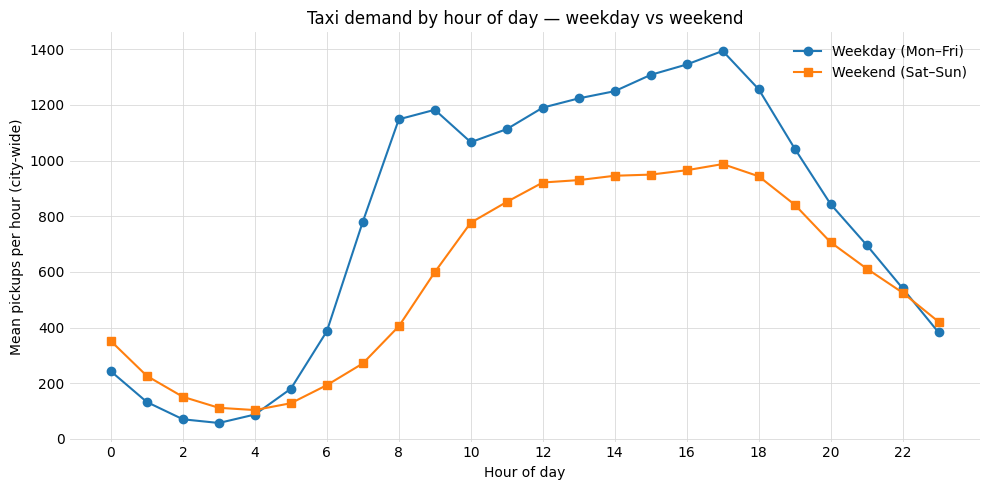

In [4]:
wd = city_hourly_mean(WEEKDAYS)
we = city_hourly_mean(WEEKEND)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wd.index, wd.values, marker="o", label="Weekday (Mon–Fri)")
ax.plot(we.index, we.values, marker="s", label="Weekend (Sat–Sun)")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(color="0.85", linewidth=0.6)

ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean pickups per hour (city-wide)")
ax.set_title("Taxi demand by hour of day — weekday vs weekend")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**2.1b Demand by day of week**

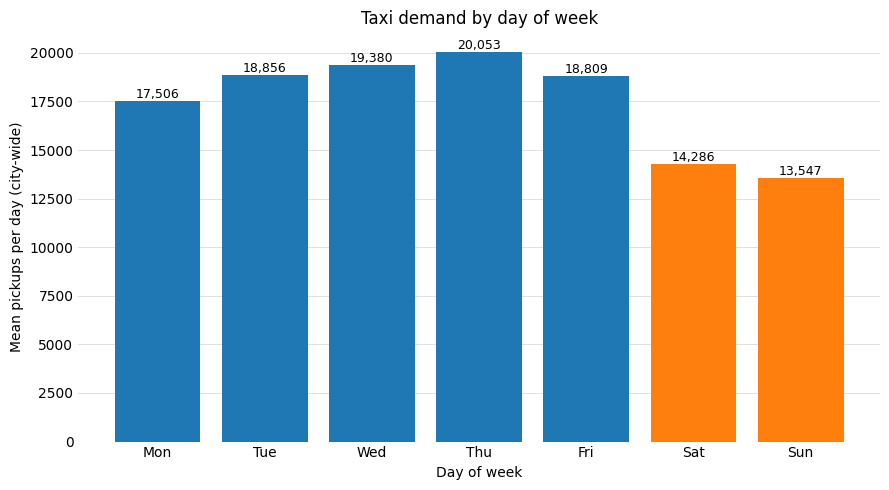

In [5]:
# Mean pickups per day, by day of week
daily = (agg_city_dow_hour.groupby("day_of_week")["n_trips"].sum())
daily_mean = pd.Series(
    {d: daily.get(d, 0) / N_DATES[d] for d in range(7)}
).reindex(range(7))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(7), daily_mean.values,
              color=["tab:blue"]*5 + ["tab:orange"]*2)  # weekend highlighted

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(axis="y", color="0.85", linewidth=0.6)

ax.set_xticks(range(7)); ax.set_xticklabels(DOW_NAMES)
ax.set_xlabel("Day of week"); ax.set_ylabel("Mean pickups per day (city-wide)")
ax.set_title("Taxi demand by day of week")

for b, v in zip(bars, daily_mean.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

**2.1c Weekday × hour heatmap**


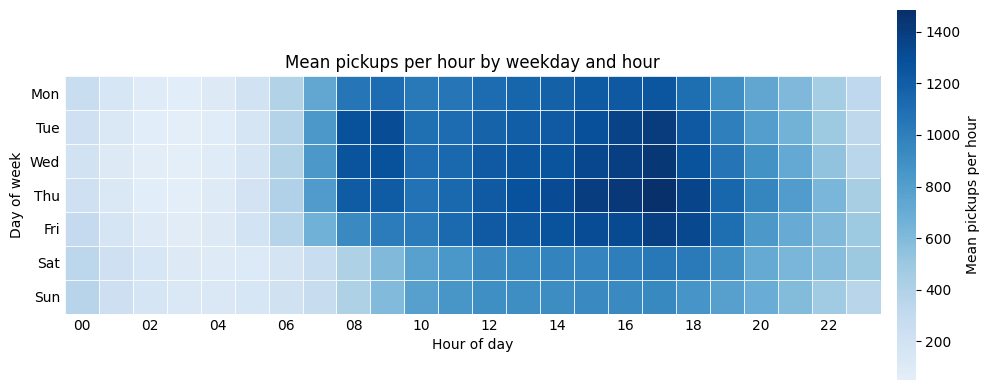

In [59]:
mat = np.full((7, 24), np.nan)
for _, r in agg_city_dow_hour.iterrows():
    d, h = int(r["day_of_week"]), int(r["hour"])
    mat[d, h] = r["n_trips"] / N_DATES[d]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(mat, aspect="equal", cmap=BLUES_DARK)

# thin white gridlines between cells
ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 7, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# no black border around the plot
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_yticks(range(7)); ax.set_yticklabels(DOW_NAMES)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 2)])
ax.set_xlabel("Hour of day"); ax.set_ylabel("Day of week")
ax.set_title("Mean pickups per hour by weekday and hour")

cbar = fig.colorbar(im, ax=ax, label="Mean pickups per hour", fraction=0.035, pad=0.02)
cbar.outline.set_visible(False)

plt.tight_layout(); plt.show()

**2.1d Monthly demand profile**


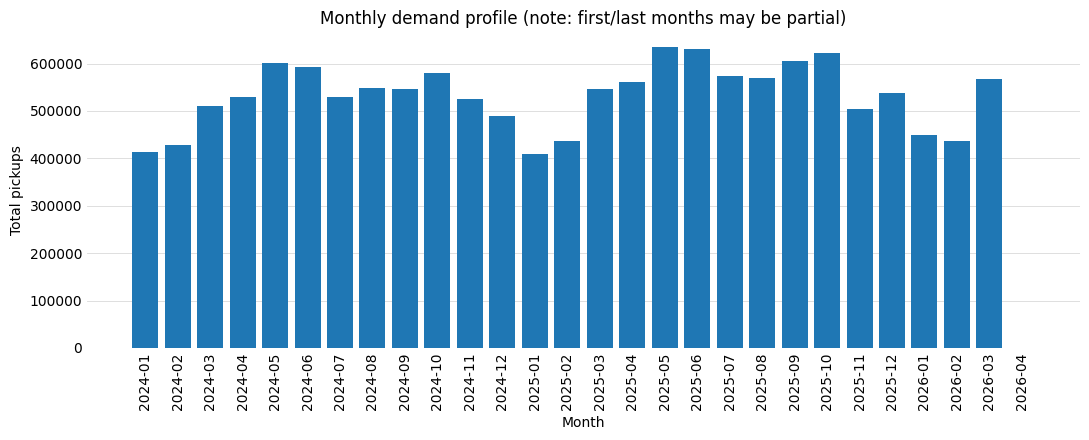

In [7]:
# Monthly demand profile over the full sample
m = agg_city_month.sort_values("month_start")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(m["month_start"].dt.strftime("%Y-%m"), m["n_trips"], color="tab:blue")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(axis="y", color="0.85", linewidth=0.6)

ax.set_xlabel("Month"); ax.set_ylabel("Total pickups")
ax.set_title("Monthly demand profile (note: first/last months may be partial)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

Same monthly data, normalized to mean pickups per day and averaged across the ~2 years in the sample, so seasonality isn't confounded with the raw trip-count growth visible in the chart above.

Dropped partial month: 2026-04


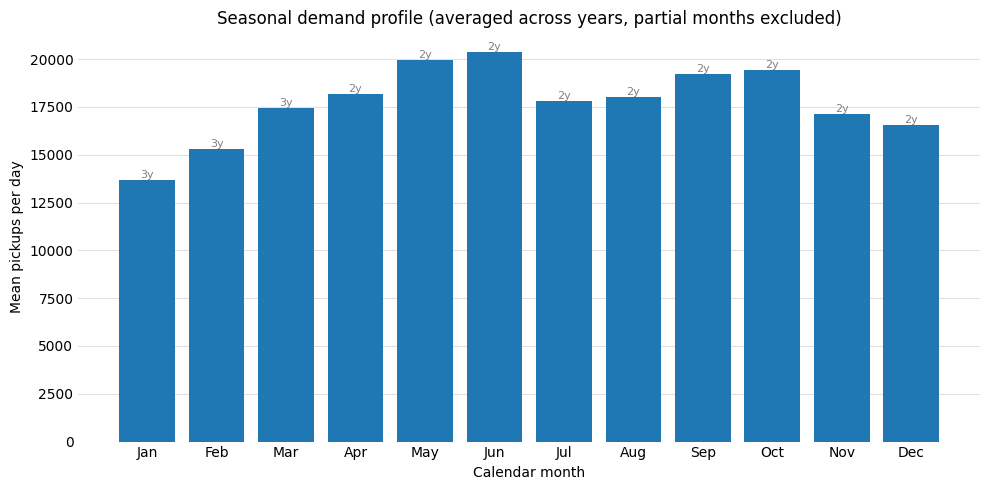

In [8]:
# Seasonal view: mean pickups per day, by calendar month (averaged across years)
# Drop the final partial month (April 2026 contains only the first few days)
m = agg_city_month.copy()
last_month = m["month_start"].max()
m = m[m["month_start"] != last_month]
print(f"Dropped partial month: {last_month.strftime('%Y-%m')}")

m["cal_month"] = m["month_start"].dt.month
m["year"]      = m["month_start"].dt.year
m["days_in_month"] = m["month_start"].dt.days_in_month

m["daily_mean"] = m["n_trips"] / m["days_in_month"]
seasonal = m.groupby("cal_month")["daily_mean"].mean().reindex(range(1, 13))
n_years  = m.groupby("cal_month")["year"].nunique().reindex(range(1, 13))

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(12), seasonal.values, color="tab:blue")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(axis="y", color="0.85", linewidth=0.6)

ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("Calendar month"); ax.set_ylabel("Mean pickups per day")
ax.set_title("Seasonal demand profile (averaged across years, partial months excluded)")
for b, n in zip(bars, n_years.values):
    if not np.isnan(b.get_height()):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(n)}y",
                ha="center", va="bottom", fontsize=8, color="grey")
plt.tight_layout(); plt.show()

**2.1e Trip-characteristic time courses by hour (weekday vs weekend)**

Distance, duration, fare and idle time per pickup hour.

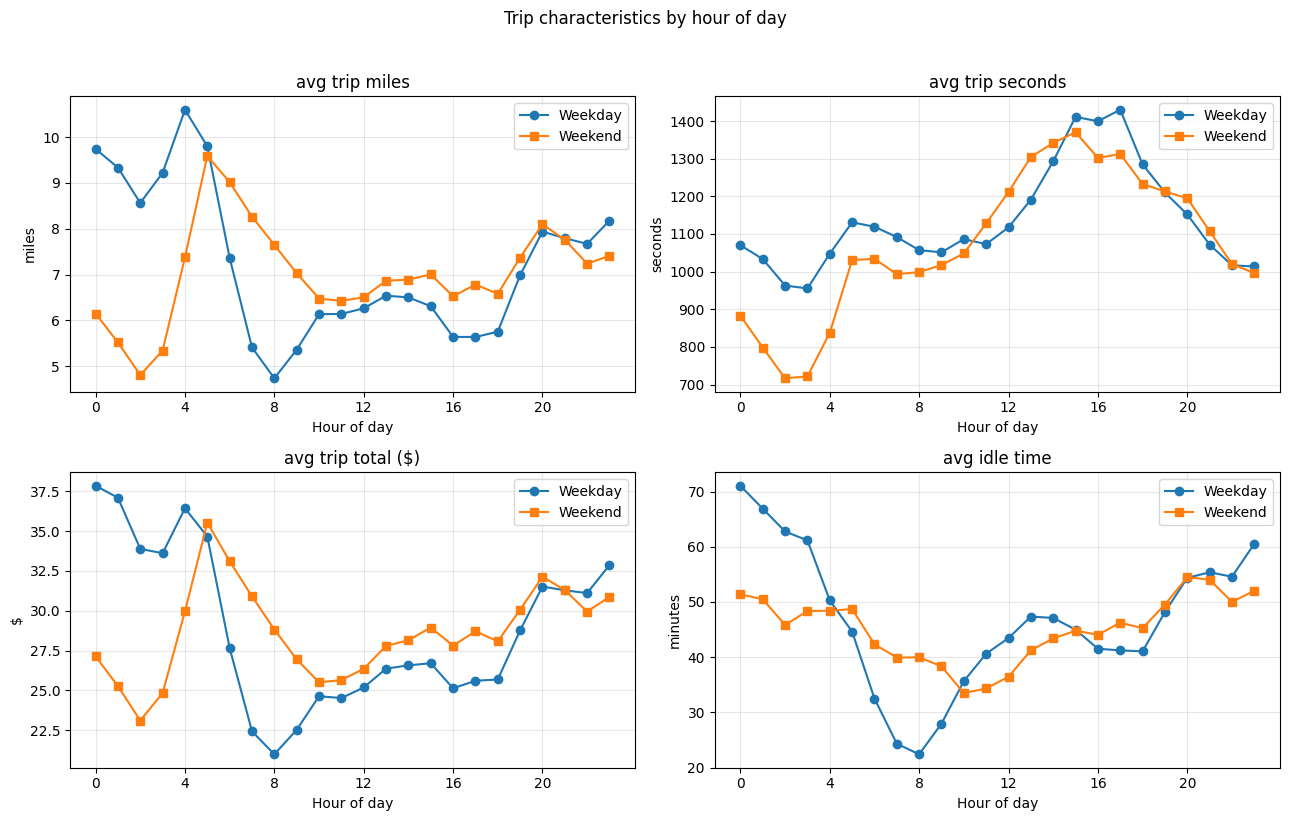

In [9]:
specs = [
    ("avg trip miles",     lambda d: city_charac_hourly("mean_trip_miles", d), "miles"),
    ("avg trip seconds",   lambda d: city_charac_hourly("mean_trip_secs", d),  "seconds"),
    ("avg trip total ($)", lambda d: city_charac_hourly("mean_trip_total", d), "$"),
    ("avg idle time",      lambda d: idle_hourly(d) / 60.0,                    "minutes"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, fn, unit) in zip(axes.ravel(), specs):
    ax.plot(range(24), fn(WEEKDAYS).values, marker="o", label="Weekday")
    ax.plot(range(24), fn(WEEKEND).values,  marker="s", label="Weekend")
    ax.set_title(title); ax.set_xlabel("Hour of day"); ax.set_ylabel(unit)
    ax.set_xticks(range(0, 24, 4)); ax.grid(True, alpha=0.3); ax.legend()
fig.suptitle("Trip characteristics by hour of day", y=1.02)
plt.tight_layout(); plt.show()


**2.1f Resolution beat: 1-hour vs 4-hour temporal binning**

The same city-wide demand, viewed at hourly resolution and at 4-hour resolution. Coarser binning
smooths the curve and hides the sharp commuting peaks. The first concrete demonstration of how
temporal resolution changes the observed pattern (expanded systematically in 2.7).

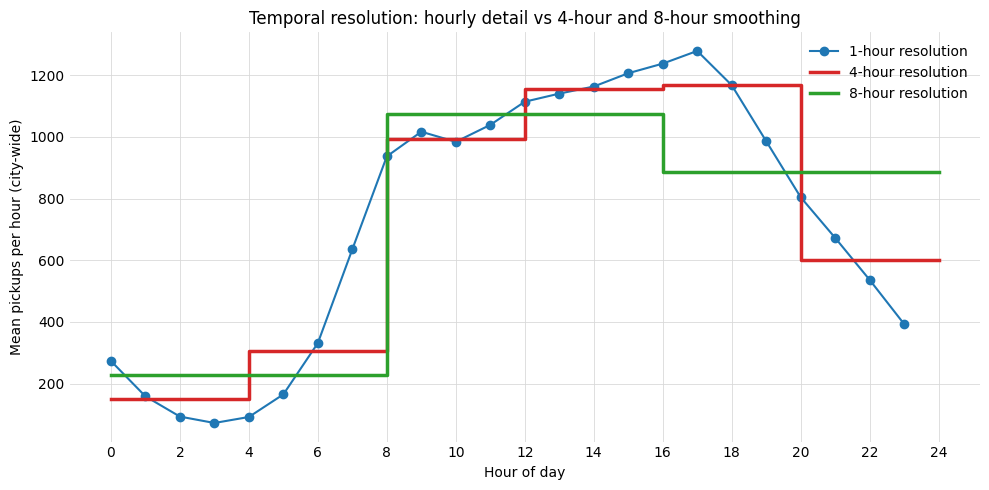

In [10]:
hourly_all = city_hourly_mean(WEEKDAYS + WEEKEND)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(24), hourly_all.values, marker="o", label="1-hour resolution")

for width, color, lbl in [(4, "tab:red", "4-hour resolution"),
                          (8, "tab:green", "8-hour resolution")]:
    binned = pd.Series(hourly_all.values).groupby(np.arange(24) // width).mean()
    x = np.arange(0, 24, width)
    # close the last bin: append x=24 and repeat the final y so the last segment is drawn
    x_closed = np.append(x, 24)
    y_closed = np.append(binned.values, binned.values[-1])
    ax.step(x_closed, y_closed, where="post", linewidth=2.5, color=color, label=lbl)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(color="0.85", linewidth=0.6)

ax.set_xticks(range(0, 25, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per hour (city-wide)")
ax.set_title("Temporal resolution: hourly detail vs 4-hour and 8-hour smoothing")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### Takeaways from 2.1

City-wide demand shows a classic two-hump commute pattern with the major peak around 5pm. Weekdays are clearly busier than weekends. Seasonally, demand swings almost 50% between the June high and the January low and on average the winter months are less busy than in summer.

### 2.2 Spatial Patterns and Hotspot Identification
Demand is aggregated over all hours and shown spatially through two complementary methods.

Grid-based:
- Choropleth of `demand_count` on Community Areas
- Choropleth of `demand_count` on H3 r6 cells (default spatial unit)

Grid-free:
- Gaussian Mixture Model fitted on raw pickup coordinates (latitude, longitude), with the number of components selected via BIC
- Kernel Density Estimation on the same coordinates, plotted as contour map over Chicago

GMM is mandatory per the task description. KDE is added because the cluster centres from GMM do not visualise density gradients well; the contour map fills that gap. The grid-vs-grid-free comparison is the substantive point: if natural pickup clusters do not align with Community Area boundaries, the administrative units are the wrong service-zone proxy.


**2.2a H3 choropleths across resolutions**

Demand is highly concentrated (the Loop and the two airports dominate), so a shared log colour scale is
used. A larger r8-only plot follows since the 6-panel grid is too small to read fine-grained detail at that resolution.

C:\Users\katig\AppData\Local\Temp\ipykernel_10004\3296464165.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_outline = gpd.read_file(CA_GEOJSON).unary_union


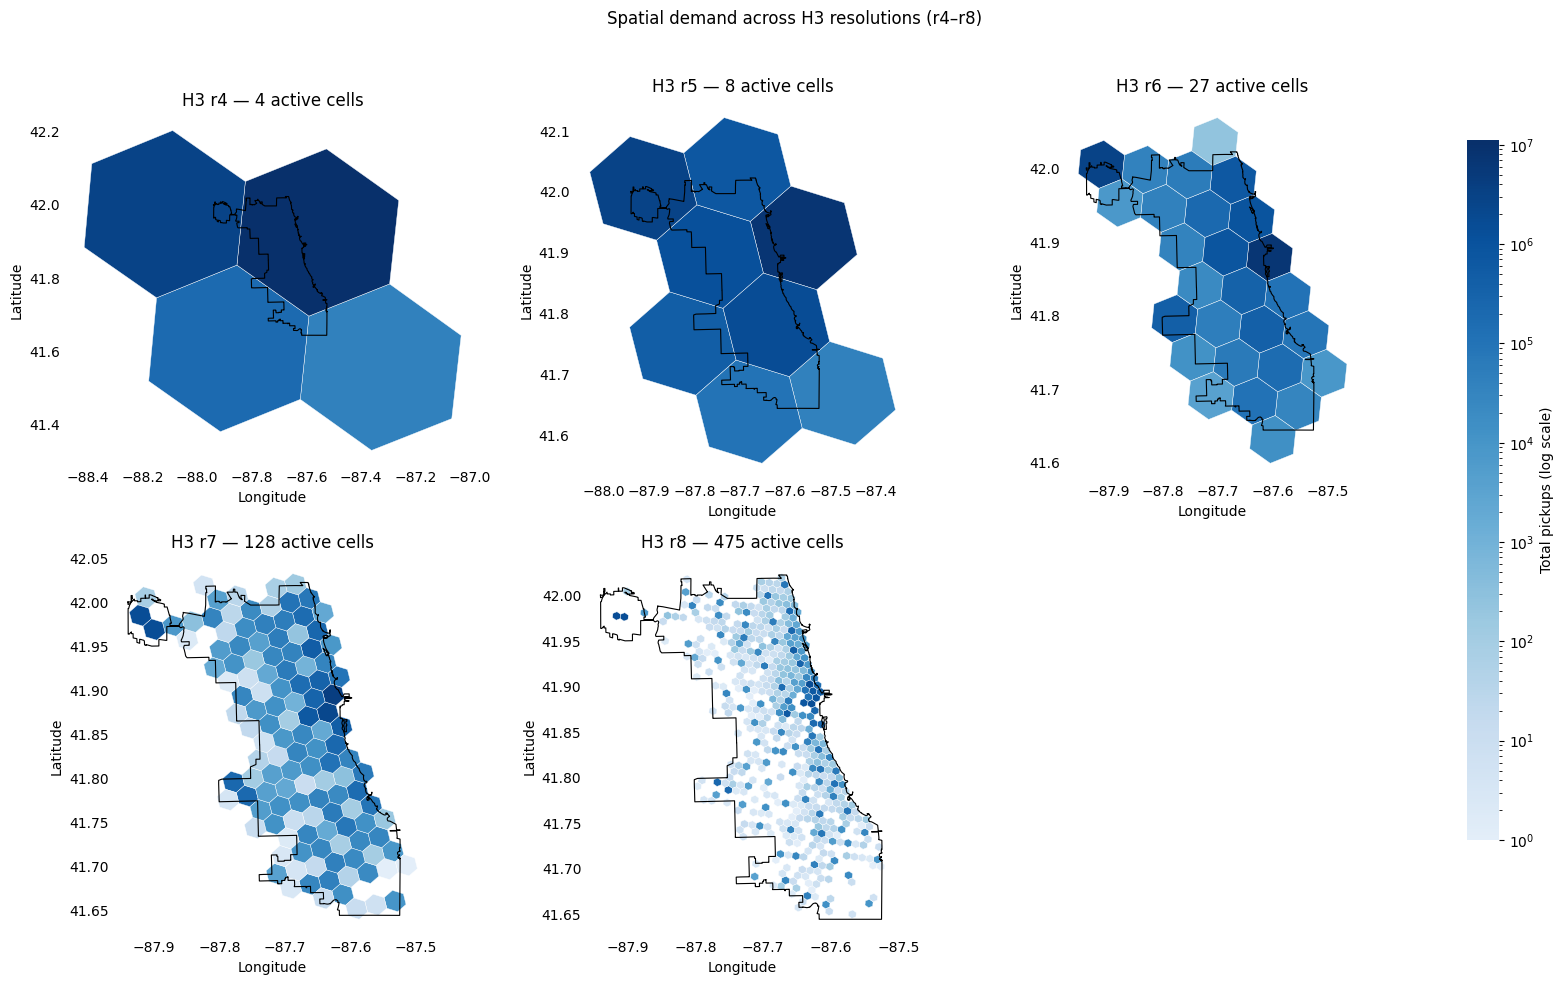

In [60]:
import pathlib
import geopandas as gpd

r4 = dict(zip(agg_h3r4_total["h3_r4"], agg_h3r4_total["n_trips"]))
r5 = dict(zip(agg_h3r5_total["h3_r5"], agg_h3r5_total["n_trips"]))
r6 = dict(zip(agg_h3r6_total["h3_r6"], agg_h3r6_total["n_trips"]))
r7 = dict(zip(agg_h3r7_total["h3_r7"], agg_h3r7_total["n_trips"]))
r8 = dict(zip(agg_h3r8_total["h3_r8"], agg_h3r8_total["n_trips"]))

panels = [("r4", r4), ("r5", r5), ("r6", r6), ("r7", r7), ("r8", r8)]
vmax = max(max(d.values()) for _, d in panels)
norm = LogNorm(vmin=1, vmax=vmax)

# Chicago city outline, dissolved from the same community-area boundaries used in 2.2b
CA_GEOJSON = pathlib.Path("../data/chicago_community_areas.geojson")
if not CA_GEOJSON.exists():
    import urllib.request
    CA_GEOJSON.parent.mkdir(parents=True, exist_ok=True)
    url = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
    urllib.request.urlretrieve(url, CA_GEOJSON)

city_outline = gpd.read_file(CA_GEOJSON).unary_union
outline_parts = city_outline.geoms if city_outline.geom_type == "MultiPolygon" else [city_outline]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axflat = axes.ravel()
pc = None
for ax, (name, d) in zip(axflat, panels):
    pc = draw_hex_choropleth(ax, d, norm=norm, cmap=BLUES_DARK,
                             title=f"H3 {name} — {len(d)} active cells")
    for poly in outline_parts:
        x, y = poly.exterior.xy
        ax.plot(x, y, color="black", linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0)

axflat[len(panels)].set_visible(False)   # hide unused 6th slot

fig.suptitle("Spatial demand across H3 resolutions (r4–r8)", y=0.98)
fig.tight_layout(rect=[0, 0, 0.90, 0.96])
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(pc, cax=cax, label="Total pickups (log scale)")
cbar.outline.set_visible(False)
plt.show()


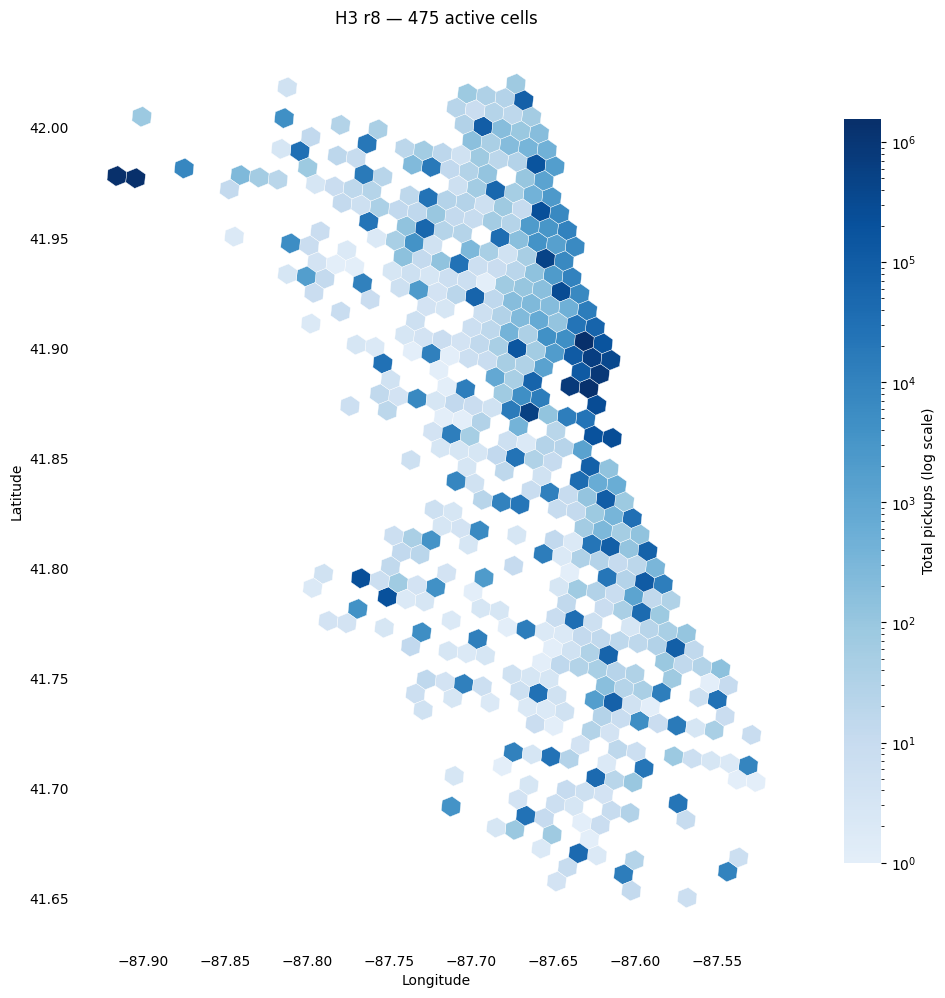

In [62]:
# Focus on r8 only
r8 = dict(zip(agg_h3r8_total["h3_r8"], agg_h3r8_total["n_trips"]))
norm = LogNorm(vmin=1, vmax=max(r8.values()))

fig, ax = plt.subplots(figsize=(10, 11))
pc = draw_hex_choropleth(ax, r8, norm=norm, cmap=BLUES_DARK,
                         title=f"H3 r8 — {len(r8)} active cells")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

cbar = fig.colorbar(pc, ax=ax, label="Total pickups (log scale)", shrink=0.7)
cbar.outline.set_visible(False)
plt.tight_layout()
plt.show()

**2.2b Community Area choropleth (administrative units)**

Requires the Chicago Community Area boundaries (a GeoJSON not contained in the trip data). The
next cell downloads them automatically on first run if missing. If `geopandas` itself isn't
installed, a ranked bar chart of the top areas is shown as a fallback instead.


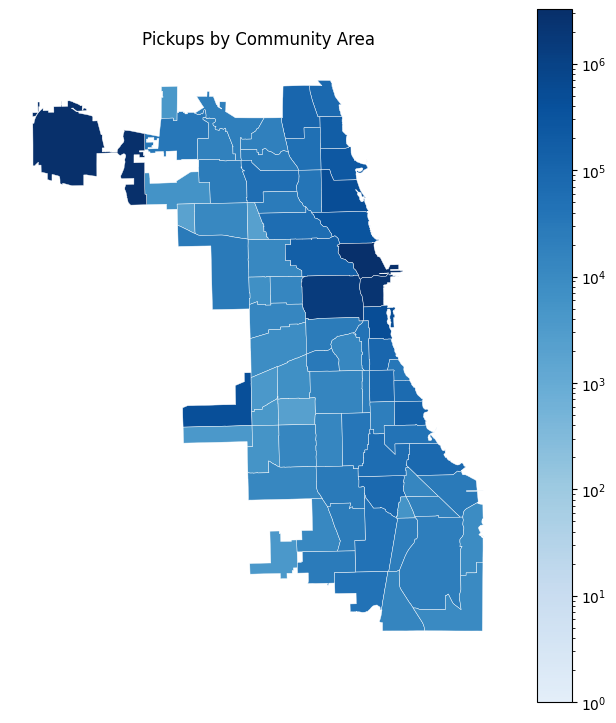

In [63]:
CA_GEOJSON = pathlib.Path("../data/chicago_community_areas.geojson")

# Download boundaries once if missing
if not CA_GEOJSON.exists():
    import urllib.request
    CA_GEOJSON.parent.mkdir(parents=True, exist_ok=True)
    url = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
    urllib.request.urlretrieve(url, CA_GEOJSON)
    print("Downloaded:", CA_GEOJSON.stat().st_size, "bytes")

def _norm(s):
    # normalize CA keys to plain integer strings ("32.0" -> "32") for a clean join
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

ca = agg_ca_total.copy()
ca["pickup_community_area"] = _norm(ca["pickup_community_area"])

drawn = False
try:
    import geopandas as gpd
    if CA_GEOJSON.exists():
        gdf = gpd.read_file(CA_GEOJSON)
        # CA number field (this file: 'area_num_1' / 'area_numbe')
        key = next((c for c in ["area_num_1", "area_numbe", "community", "area_number"]
                    if c in gdf.columns), None)
        gdf["_key"] = _norm(gdf[key])
        gdf = gdf.merge(ca, left_on="_key", right_on="pickup_community_area", how="left")
        fig, ax = plt.subplots(figsize=(8, 9))
        gdf.plot(column="n_trips", cmap=BLUES_DARK, legend=True, ax=ax,
                 norm=LogNorm(vmin=1, vmax=ca["n_trips"].max()),
                 missing_kwds={"color": "lightgrey"}, edgecolor="white", linewidth=0.3)
        ax.set_title("Pickups by Community Area"); ax.set_axis_off()
        plt.show(); drawn = True
    else:
        print(f"GeoJSON not found at {CA_GEOJSON}")
except ModuleNotFoundError:
    print("geopandas not installed — run: uv add geopandas")

if not drawn:
    top = ca.sort_values("n_trips", ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top["pickup_community_area"][::-1], top["n_trips"][::-1], color="tab:blue")

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0)

    ax.set_axisbelow(True)
    ax.grid(axis="x", color="0.85", linewidth=0.6)

    ax.set_xlabel("Total pickups"); ax.set_ylabel("Community Area")
    ax.set_title("Top 20 Community Areas by pickups (fallback)")
    plt.tight_layout(); plt.show()

**2.2c Gaussian Mixture Model on raw pickup coordinates (BIC-selected)**

GMM is fitted on the raw `(lat, lng)` points. The full 14M points are infeasible to fit directly, so the model is fitted on a random sample. BIC
keeps decreasing well past n=30 on raw coordinates (finer partitions always fit marginally
better), so it can't serve as a stopping rule on its own here. We cap at **8 components** for
interpretability. 

Total coordinate points available: 14,380,962
Fitting GMM on a sample of 500,000 points
Using capped n_components = 9 (BIC-minimising n within the tested range would be 15, but keeps falling beyond it, see note above)


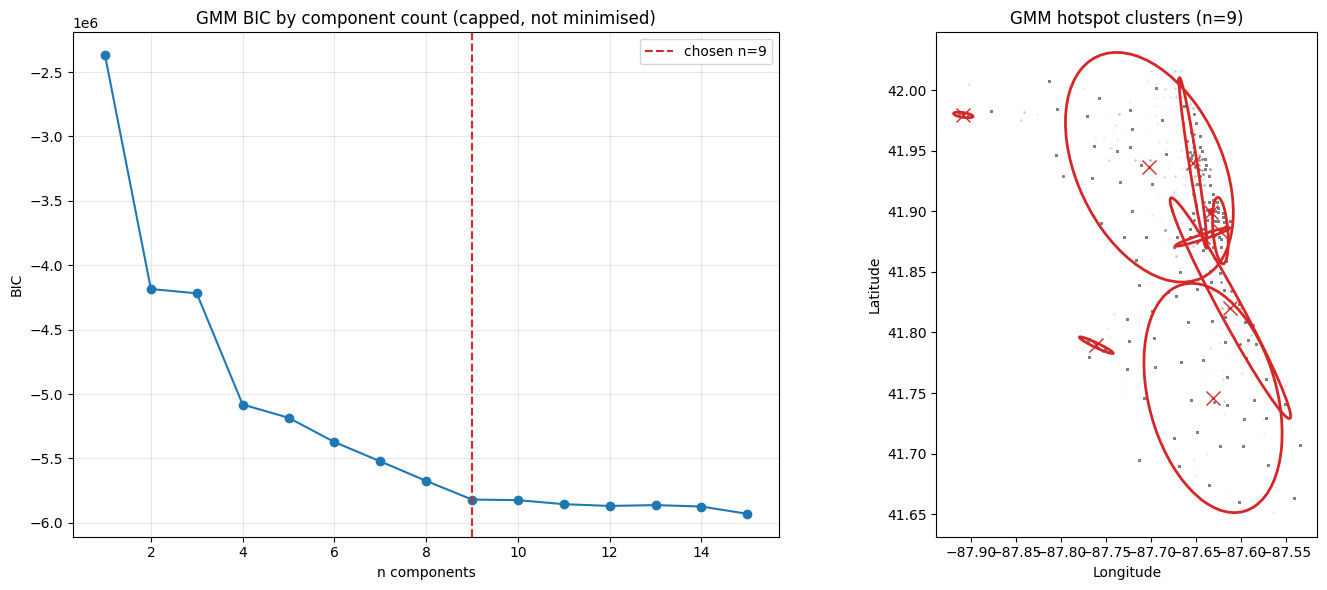

In [19]:
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

coords = pd.read_parquet(PROCESSED / "slim_trips.parquet",
                         columns=["pickup_centroid_latitude", "pickup_centroid_longitude"]).dropna()
coords = coords.astype("float64")
print(f"Total coordinate points available: {len(coords):,}")

rng = np.random.default_rng(42)
SAMPLE_N = min(500_000, len(coords))
idx = rng.choice(len(coords), size=SAMPLE_N, replace=False)
X = coords.to_numpy()[idx]          # columns: [lat, lng]
print(f"Fitting GMM on a sample of {SAMPLE_N:,} points")

# Unbounded BIC search never converges to a usable hotspot count. We cap
# at n=8 for interpretability. The BIC curve below is shown for context,
# not as the selection rule.
ns = range(1, 16)
bics = []
for n in ns:
    g = GaussianMixture(n_components=n, covariance_type="full", random_state=0, n_init=1)
    g.fit(X)
    bics.append(g.bic(X))

N_COMPONENTS = 9
gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type="full",
                      init_params="k-means++", n_init=5, random_state=0).fit(X)
print(f"Using capped n_components = {N_COMPONENTS} (BIC-minimising n within the tested range "
      f"would be {list(ns)[int(np.argmin(bics))]}, but keeps falling beyond it, see note above)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(list(ns), bics, marker="o")
axes[0].axvline(N_COMPONENTS, color="tab:red", ls="--", label=f"chosen n={N_COMPONENTS}")
axes[0].set_xlabel("n components"); axes[0].set_ylabel("BIC")
axes[0].set_title("GMM BIC by component count (capped, not minimised)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X[:, 1], X[:, 0], s=1, alpha=0.04, color="grey")  # lng, lat
for k in range(N_COMPONENTS):
    mean = gmm.means_[k]                 # [lat, lng]
    cov = gmm.covariances_[k][np.ix_([1, 0], [1, 0])]   # reorder to [lng, lat]
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * np.sqrt(vals) * 2        # ~2 std
    ax.add_patch(Ellipse((mean[1], mean[0]), w, h, angle=angle,
                         fill=False, edgecolor="tab:red", linewidth=2))
    ax.plot(mean[1], mean[0], "x", color="tab:red", markersize=10)
ax.set_aspect(1 / np.cos(np.radians(41.88)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"GMM hotspot clusters (n={N_COMPONENTS})")
plt.tight_layout(); plt.show()

The plots above show discrete component centres, this renders the GMM's fitted density as a
continuous surface instead, using the same grid/contour style as the KDE in 2.2d, so the
parametric (GMM) and nonparametric (KDE) density estimates can be compared directly.

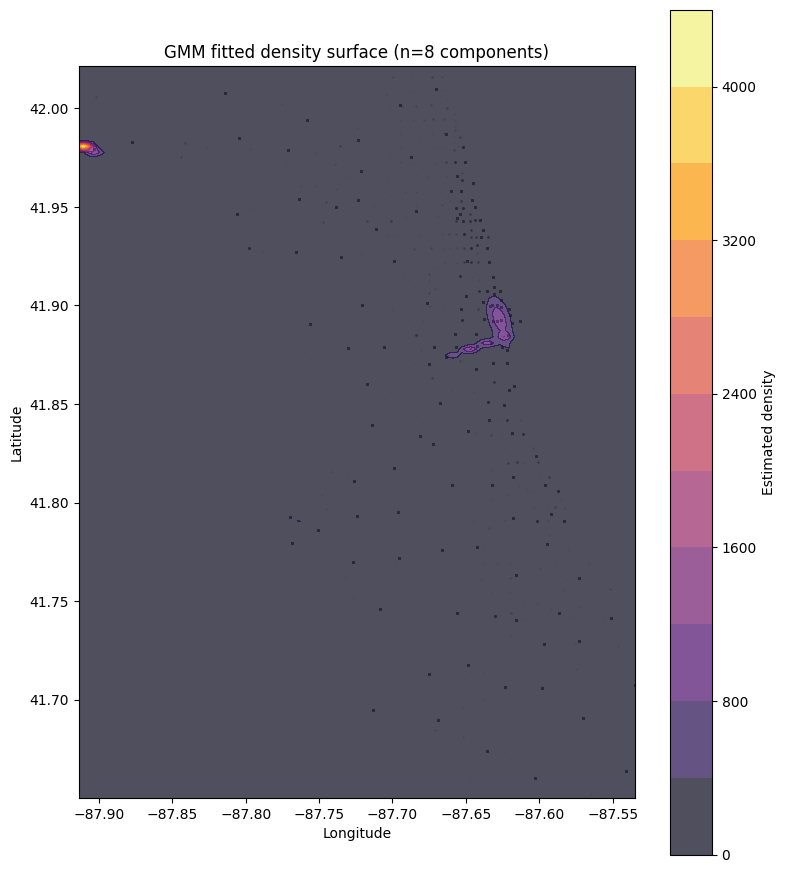

In [19]:
# GMM's own fitted density, rendered the same way as the KDE contour below
gx, gy = np.mgrid[X[:, 1].min():X[:, 1].max():120j, X[:, 0].min():X[:, 0].max():120j]  # lng, lat
grid_pts = np.column_stack([gy.ravel(), gx.ravel()])   # score_samples expects [lat, lng]
dens_gmm = np.exp(gmm.score_samples(grid_pts)).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(X[:, 1], X[:, 0], s=1, alpha=0.04, color="grey")
cf = ax.contourf(gx, gy, dens_gmm, levels=12, cmap="inferno", alpha=0.7)
ax.set_aspect(1 / np.cos(np.radians(41.88)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"GMM fitted density surface (n={N_COMPONENTS} components)")
fig.colorbar(cf, ax=ax, label="Estimated density")
plt.tight_layout(); plt.show()

**2.2d Kernel Density Estimation contour**

KDE visualises the continuous density gradient that GMM's discrete clusters cannot. Evaluated on a
grid over Chicago and shown as filled contours over a faint scatter of the sample.

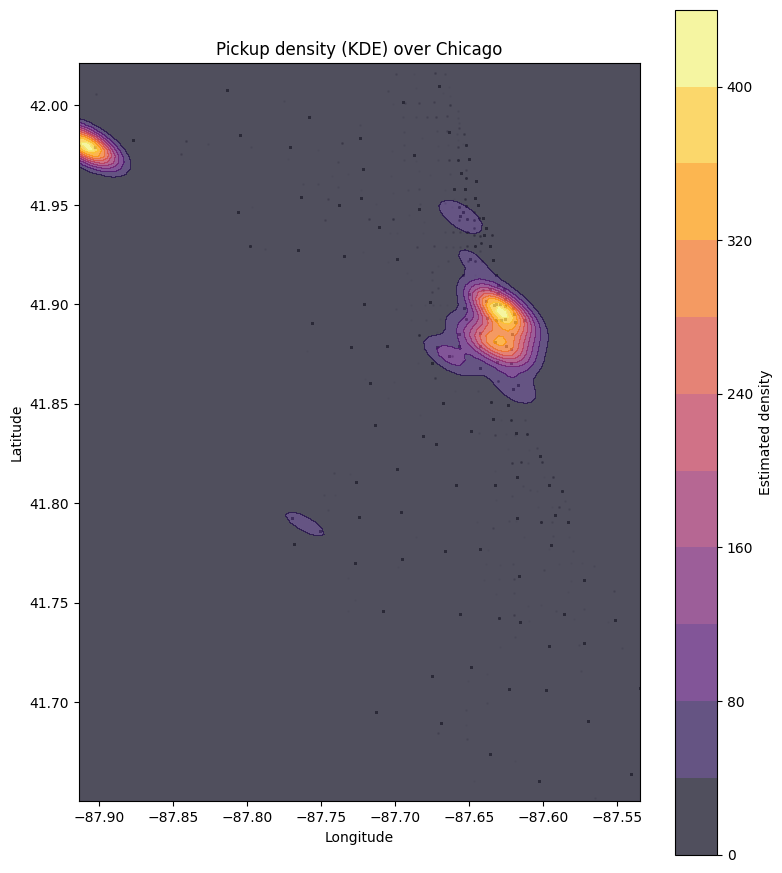

In [20]:
from scipy.stats import gaussian_kde

KDE_N = min(500_000, len(X))          
sub = X[rng.choice(len(X), size=KDE_N, replace=False)]
lat_s, lng_s = sub[:, 0], sub[:, 1]

kde = gaussian_kde(np.vstack([lng_s, lat_s]))
lng_min, lng_max = lng_s.min(), lng_s.max()
lat_min, lat_max = lat_s.min(), lat_s.max()
gx, gy = np.mgrid[lng_min:lng_max:120j, lat_min:lat_max:120j]
dens = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(lng_s, lat_s, s=1, alpha=0.05, color="grey")
cf = ax.contourf(gx, gy, dens, levels=12, cmap="inferno", alpha=0.7)
ax.set_aspect(1 / np.cos(np.radians(41.88)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Pickup density (KDE) over Chicago")
fig.colorbar(cf, ax=ax, label="Estimated density")
plt.tight_layout(); plt.show()


### 2.3 Spatio-Temporal Interplay
`demand_count` is shown jointly over (spatial unit × time). Three artefacts:

- Heatmap matrix: rows = top-N H3 r6 cells (or Community Areas), columns = hour of day, colour = mean `demand_count`
- Small multiples: demand maps at four representative hours (1am, 7am, 1pm, 7pm) on a typical weekday, repeated for Saturday -> eight panels total, choropleth on the same spatial unit as 2.2
- Line plot: hourly demand profile for the top hexagons over a typical day

The three artefacts exist because no single plot captures both dimensions well. The matrix is dense and exact but loses geography, the small multiples retain geography but lose continuity, the line plot makes the dynamics of individual hotspots readable.

**2.3a Heatmap matrix: top-N H3 r6 cells × hour of day**

Rows are the busiest r6 cells, columns are hour of day, colour is mean pickups per hour. A log
colour scale keeps the airport/Loop cells from flattening everything else.


Top H3 r6 cells by demand:
  # 1  862664c1fffffff  (41.8794, -87.6055)   46.8%
  # 2  862759347ffffff  (42.0059, -87.9126)   20.7%
  # 3  862664c17ffffff  (41.9319, -87.6387)    6.6%
  # 4  862664cafffffff  (41.8866, -87.6855)    6.1%
  # 5  862664d8fffffff  (41.9844, -87.6720)    4.5%
  # 6  862664527ffffff  (41.7962, -87.7788)    3.0%
  # 7  862664cc7ffffff  (41.7817, -87.6191)    2.6%
  # 8  862664cf7ffffff  (41.8342, -87.6523)    2.3%
  # 9  862664ca7ffffff  (41.9391, -87.7188)    1.5%
  #10  862664ccfffffff  (41.7293, -87.5860)    1.1%
  #11  862664567ffffff  (41.6842, -87.6327)    0.8%
  #12  862664ce7ffffff  (41.8269, -87.5723)    0.7%


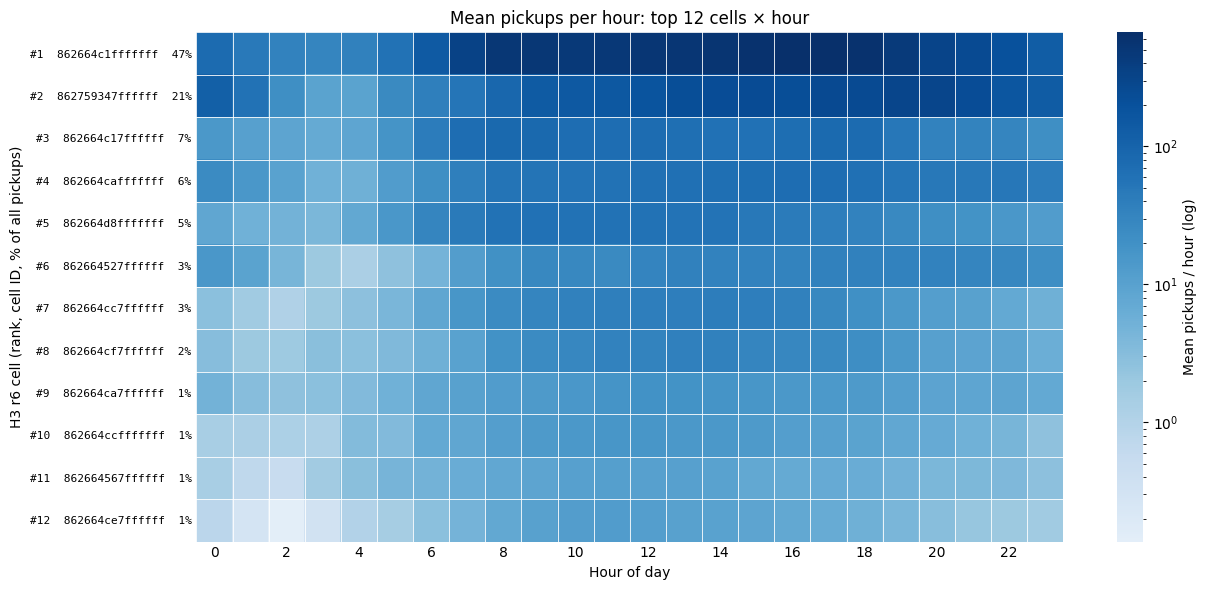

In [64]:
import h3

N_TOP = 12
cell_tot = agg_h3r6_dow_hour.groupby("h3_r6")["n_trips"].sum().sort_values(ascending=False)
top_cells = cell_tot.head(N_TOP).index.tolist()
total_all = cell_tot.sum()

# Label cells by rank, H3 cell ID, centroid coordinates, and share of all pickups
print("Top H3 r6 cells by demand:")
labels = []
for rank, c in enumerate(top_cells, 1):
    lat, lng = h3.cell_to_latlng(c)
    share = cell_tot[c] / total_all * 100
    print(f"  #{rank:>2}  {c}  ({lat:.4f}, {lng:.4f})  {share:5.1f}%")
    labels.append(f"#{rank}  {c}  {share:.0f}%")

# Mean pickups per hour-of-day
hour_of_day = (agg_h3r6_dow_hour.groupby(["h3_r6", "hour"])["n_trips"].sum()
               / TOTAL_DATES).rename("mean_demand").reset_index()
pivot = (hour_of_day[hour_of_day["h3_r6"].isin(top_cells)]
         .pivot(index="h3_r6", columns="hour", values="mean_demand")
         .reindex(index=top_cells, columns=range(24)).fillna(0)
         .astype("float64"))

# Heatmap
fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap=BLUES_DARK,
               norm=LogNorm(vmin=max(pivot.values[pivot.values > 0].min(), 0.1),
                            vmax=pivot.values.max()))

ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
ax.set_yticks(np.arange(-0.5, N_TOP, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_yticks(range(N_TOP)); ax.set_yticklabels(labels, fontsize=8, fontfamily="monospace")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("H3 r6 cell (rank, cell ID, % of all pickups)")
ax.set_title(f"Mean pickups per hour: top {N_TOP} cells × hour")
cbar = fig.colorbar(im, ax=ax, label="Mean pickups / hour (log)")
cbar.outline.set_visible(False)
plt.tight_layout(); plt.show()

**2.3b Small multiples: demand maps at representative time slices**

The spatial footprint of demand at four hours of a typical weekday, plus the same hours on
Saturday. All panels share one colour scale so they are directly comparable.


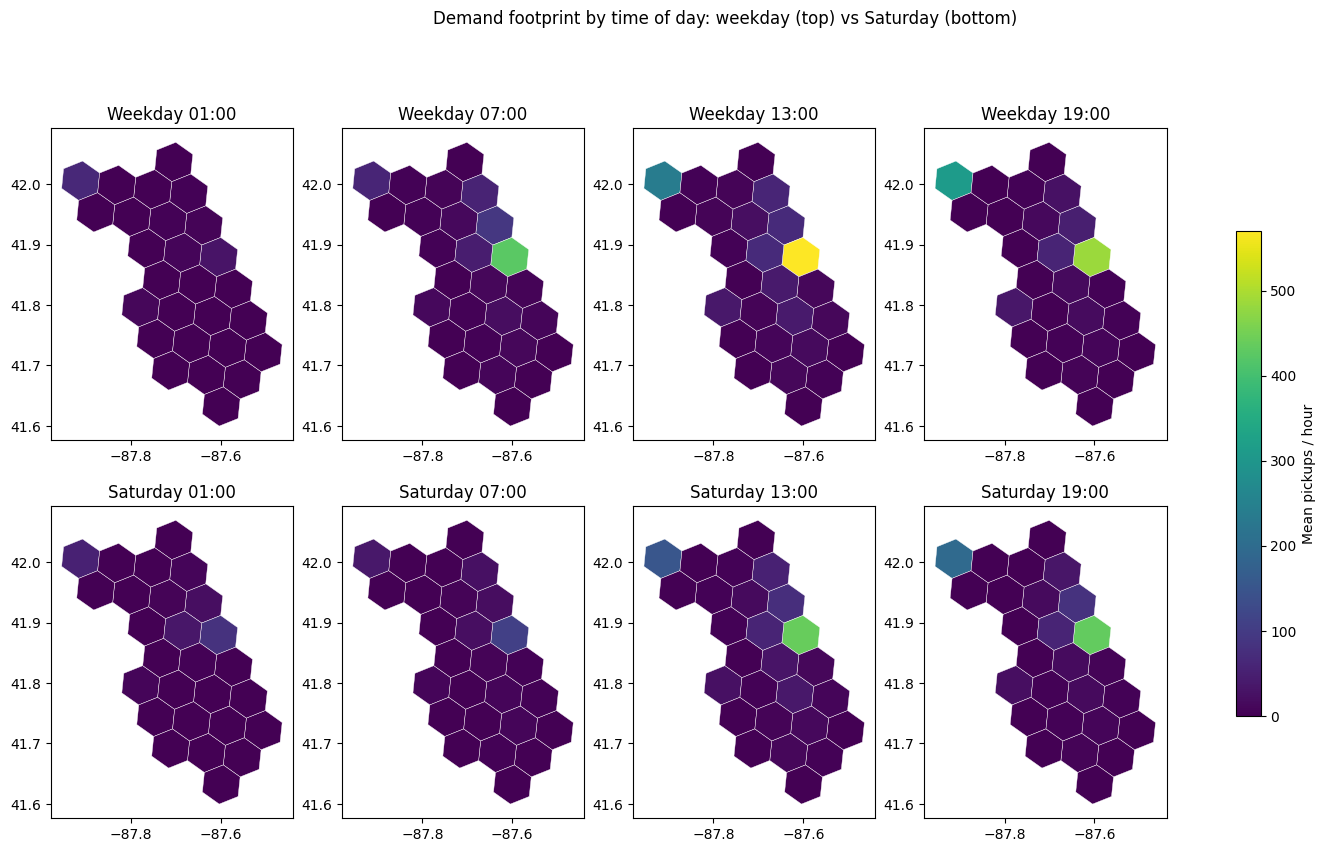

In [23]:
def cell_demand_at(hour, dows):
    sub = agg_h3r6_dow_hour[(agg_h3r6_dow_hour["hour"] == hour) &
                            (agg_h3r6_dow_hour["day_of_week"].isin(dows))]
    n_days = sum(N_DATES[d] for d in dows)
    s = sub.groupby("h3_r6")["n_trips"].sum() / n_days
    return s.to_dict()

slices = [(1, "01:00"), (7, "07:00"), (13, "13:00"), (19, "19:00")]
all_cells = agg_h3r6_total["h3_r6"].tolist()

# global vmax across all panels for a shared scale
panel_data = []
for h, lbl in slices:
    panel_data.append((f"Weekday {lbl}", cell_demand_at(h, WEEKDAYS)))
for h, lbl in slices:
    panel_data.append((f"Saturday {lbl}", cell_demand_at(h, [5])))
gmax = max((max(d.values()) if d else 0) for _, d in panel_data)
norm = Normalize(vmin=0, vmax=gmax)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, d) in zip(axes.ravel(), panel_data):
    full = {c: d.get(c, 0.0) for c in all_cells}   # show 0 for inactive cells
    pc = draw_hex_choropleth(ax, full, norm=norm, title=title, edgecolor="white")
    ax.set_xlabel(""); ax.set_ylabel("")
fig.colorbar(pc, ax=axes, label="Mean pickups / hour", shrink=0.7)
fig.suptitle("Demand footprint by time of day: weekday (top) vs Saturday (bottom)", y=1.01)
plt.show()


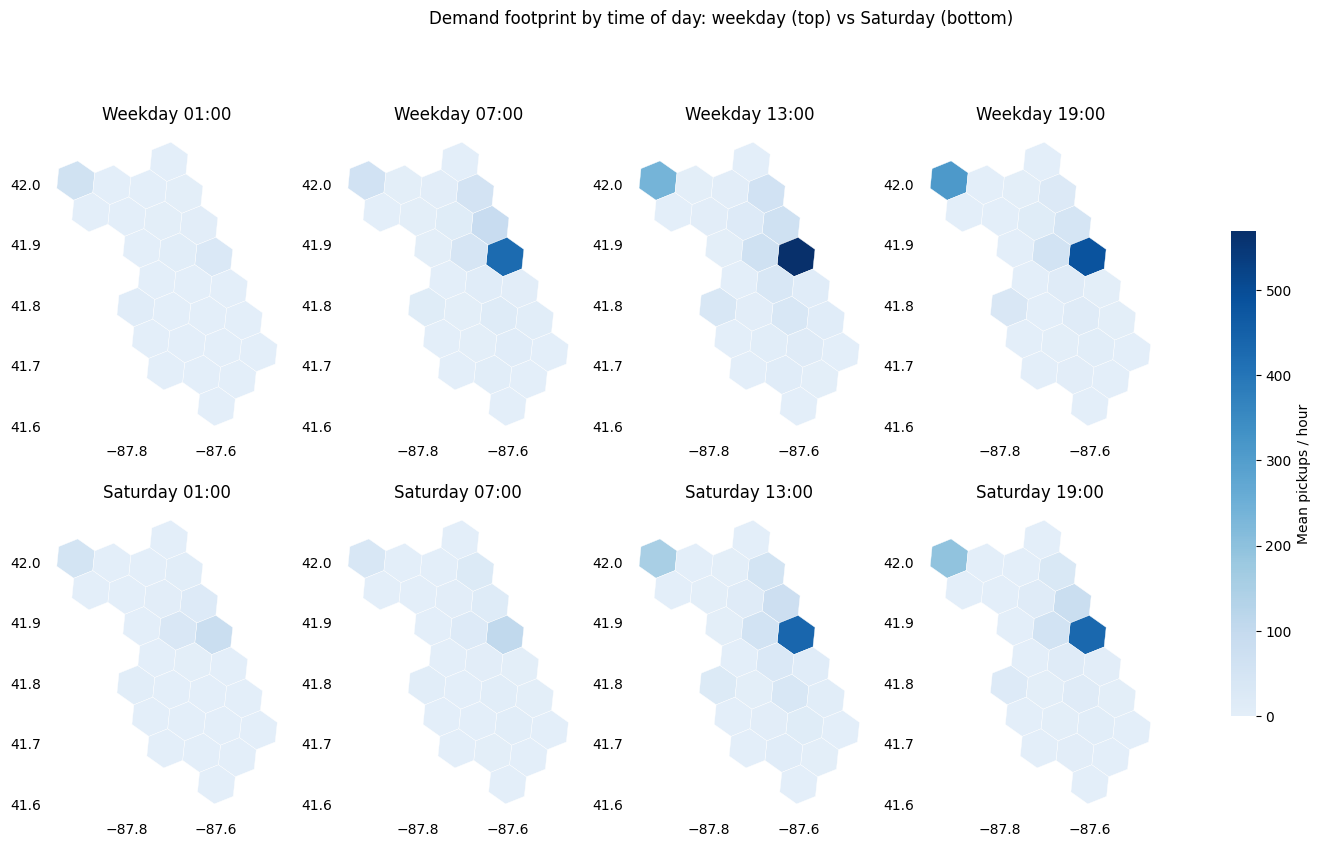

In [68]:
def cell_demand_at(hour, dows):
    sub = agg_h3r6_dow_hour[(agg_h3r6_dow_hour["hour"] == hour) &
                            (agg_h3r6_dow_hour["day_of_week"].isin(dows))]
    n_days = sum(N_DATES[d] for d in dows)
    s = sub.groupby("h3_r6")["n_trips"].sum() / n_days
    return s.to_dict()

slices = [(1, "01:00"), (7, "07:00"), (13, "13:00"), (19, "19:00")]
all_cells = agg_h3r6_total["h3_r6"].tolist()

# global vmax across all panels for a shared scale
panel_data = []
for h, lbl in slices:
    panel_data.append((f"Weekday {lbl}", cell_demand_at(h, WEEKDAYS)))
for h, lbl in slices:
    panel_data.append((f"Saturday {lbl}", cell_demand_at(h, [5])))
gmax = max((max(d.values()) if d else 0) for _, d in panel_data)
norm = Normalize(vmin=0, vmax=gmax)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, d) in zip(axes.ravel(), panel_data):
    full = {c: d.get(c, 0.0) for c in all_cells}   # show 0 for inactive cells
    pc = draw_hex_choropleth(ax, full, norm=norm, title=title, edgecolor="white", cmap=BLUES_DARK)
    ax.set_xlabel(""); ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0)
cbar = fig.colorbar(pc, ax=axes, label="Mean pickups / hour", shrink=0.7)
cbar.outline.set_visible(False)
fig.suptitle("Demand footprint by time of day: weekday (top) vs Saturday (bottom)", y=1.01)
plt.show()

**2.3c Hourly demand profile for the top ten hexagons**

How the busiest cells rise and fall over a typical day. The airport cells peak differently from
the downtown cells, which is the operational reason the small multiples and the matrix are
complementary.

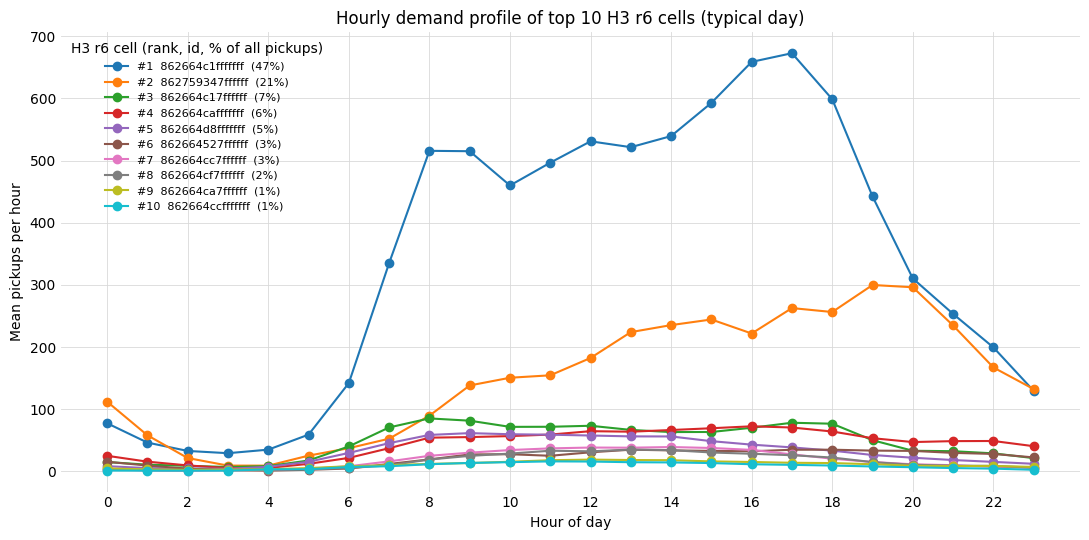

In [25]:
top10 = cell_tot.head(10).index.tolist()
total_all = cell_tot.sum()

fig, ax = plt.subplots(figsize=(11, 5.5))
for rank, c in enumerate(top10, 1):
    series = (hour_of_day[hour_of_day["h3_r6"] == c]
              .set_index("hour")["mean_demand"].reindex(range(24), fill_value=0))
    share = cell_tot[c] / total_all * 100
    ax.plot(series.index, series.values, marker="o",
            label=f"#{rank}  {c}  ({share:.0f}%)")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(color="0.85", linewidth=0.6)

ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per hour")
ax.set_title("Hourly demand profile of top 10 H3 r6 cells (typical day)")
ax.legend(title="H3 r6 cell (rank, id, % of all pickups)", fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### Takeaways from 2.3
- **Concentration:** a handful of r6 cells (Loop + airports) dominate all spatial views, log scales
  and top-N selection are used so the long tail stays visible.
- **Sampling:** GMM/KDE are fitted on coordinate samples for tractability, the full coordinate set
  is preserved upstream. Counts and choropleths use the complete data.
- **Community Area choropleth** needs an external boundary file (see 2.2b) and is the only required
  output that depends on data outside the trip table.

### 2.4 Origin-Destination Flows
Pickup → dropoff pairs are aggregated at Community Area level (H3 r6 produces too many low-volume pairs for a readable OD analysis). This section covers:

- Top 30 OD pairs as a sorted table with trip count, mean trip distance and mean trip total
- Sankey diagram of the major inter-area flows, showing where the busiest origins actually send their trips
- Asymmetry score per OD pair: `(forward − backward) / (forward + backward)`, used to flag corridors with structural repositioning need

Anchoring on pickups alone misses where vehicles end up after a trip, which is the relevant question for repositioning.

**2.4a Top 30 OD pairs (Community Area level)**

In [ ]:
agg_od_ca = _load("agg_od_ca")   # pickup_community_area, dropoff_community_area → n_trips, mean_trip_miles, mean_trip_total

def _norm_ca(s):
    """Normalise CA identifier strings: '32.0' → '32'."""
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

od = agg_od_ca.copy()
od["pickup_community_area"]  = _norm_ca(od["pickup_community_area"])
od["dropoff_community_area"] = _norm_ca(od["dropoff_community_area"])

top_od = (od.sort_values("n_trips", ascending=False)
            .head(30)
            .reset_index(drop=True))
top_od.index += 1

print(f"Total OD pairs with ≥1 trip: {len(od):,}")
display(
    top_od.style
      .format({"n_trips": "{:,.0f}",
               "mean_trip_miles": "{:.2f}",
               "mean_trip_total": "${:.2f}"})
      .background_gradient(subset=["n_trips"], cmap=BLUES_DARK)
      .set_caption("Top 30 Origin → Destination pairs by trip count (Community Area level)"))


Total OD pairs with ≥1 trip: 5,705


,pickup_community_area,dropoff_community_area,n_trips,mean_trip_miles,mean_trip_total
1,8,8,"1,111,127",0.83,$11.62
2,32,8,"686,866",1.34,$10.42
3,8,32,"648,950",1.34,$10.49
4,76,8,"589,772",17.09,$58.91
5,32,32,"584,885",0.73,$12.32
6,28,8,"417,663",1.79,$11.64
7,8,28,"392,728",1.98,$12.32
8,76,32,"377,816",17.69,$61.02
9,28,32,"370,965",1.11,$9.23
10,32,28,"356,439",1.34,$10.14


**2.4b Sankey diagram of major flows**

Within-area trips (pickup CA == dropoff CA) are excluded they are real trips but not inter-area corridors.
Top 10 Community Areas by outbound volume are shown, flows between them only.
Left side = pickup (origin), right side = dropoff (destination).

In [27]:
od_inter = od[od["pickup_community_area"] != od["dropoff_community_area"]].copy()

TOP_CA = 10

top_cas = (od_inter.groupby("pickup_community_area")["n_trips"].sum()
                   .sort_values(ascending=False).head(TOP_CA).index.tolist())
od_top = od_inter[od_inter["pickup_community_area"].isin(top_cas) &
                  od_inter["dropoff_community_area"].isin(top_cas)].copy()


import plotly.graph_objects as go

n = len(top_cas)
# Same CA label appears twice (left = pickup, right = dropoff)
src_idx = {c: i     for i, c in enumerate(top_cas)}
dst_idx = {c: i + n for i, c in enumerate(top_cas)}
labels  = [f"CA {c}" for c in top_cas] + [f"CA {c}" for c in top_cas]

fig_s = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=12, thickness=18, label=labels),
    link=dict(
        source=od_top["pickup_community_area"].map(src_idx).tolist(),
        target=od_top["dropoff_community_area"].map(dst_idx).tolist(),
        value =od_top["n_trips"].tolist(),
    ),
))
fig_s.update_layout(
    title_text=(f"OD flows — top {TOP_CA} Community Areas "
                f"(left = pickup origin, right = dropoff destination)"),
    font_size=10, height=600,
)
fig_s.show()



**2.4c Asymmetry score per corridor**

For every directed corridor A → B, the reverse flow B → A is looked up.
`asymmetry = (A→B − B→A) / (A→B + B→A)` equals +1 when fully one-directional, 0 when perfectly balanced.
High asymmetry = taxis arrive but cannot find a return trip → repositioning cost.

,pickup_community_area,dropoff_community_area,n_trips,n_reverse,asymmetry
1,76,7,"139,245","18,190",+0.769
2,76,28,"133,190","19,543",+0.744
3,76,6,"149,424","26,338",+0.700
4,76,8,"589,772","155,258",+0.583
5,76,32,"377,816","121,359",+0.514
6,8,7,"172,240","97,241",+0.278
7,8,6,"143,105","108,783",+0.136
8,32,33,"136,947","118,102",+0.074
9,28,8,"417,663","392,728",+0.031
10,32,8,"686,866","648,950",+0.028


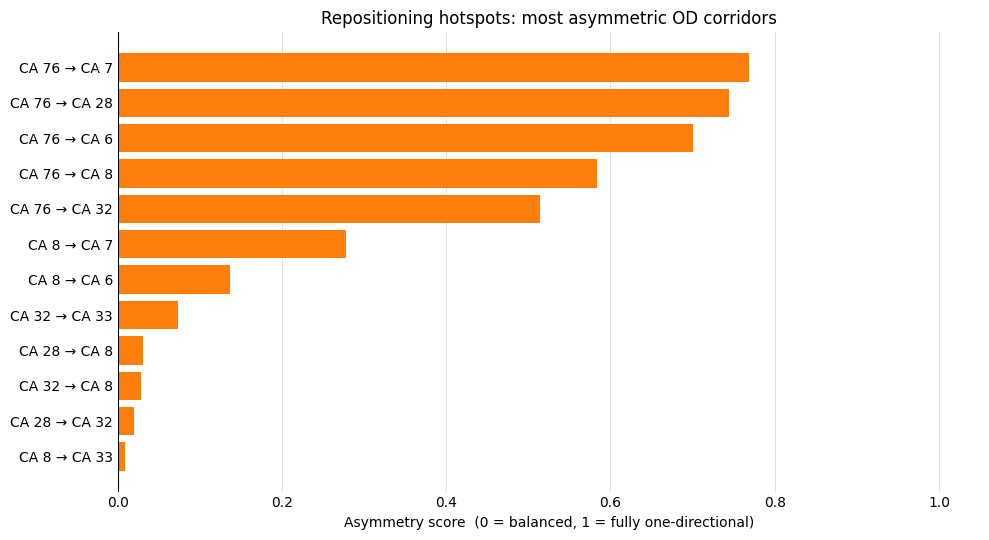

In [28]:
MIN_TRIPS = 100000

# For every directed pair (A→B), look up the reverse volume (B→A)
od_rev = od_inter[["pickup_community_area", "dropoff_community_area", "n_trips"]].rename(
    columns={"pickup_community_area":  "dropoff_community_area",
             "dropoff_community_area": "pickup_community_area",
             "n_trips":               "n_reverse"})
od_a = od_inter.merge(od_rev, on=["pickup_community_area", "dropoff_community_area"], how="left")
od_a["n_reverse"] = od_a["n_reverse"].fillna(0).astype(int)
od_a["asymmetry"] = (od_a["n_trips"] - od_a["n_reverse"]) / (od_a["n_trips"] + od_a["n_reverse"])

# Keep only the dominant direction (n_trips > n_reverse) and filter sparse corridors
od_a = od_a[(od_a["n_trips"] > od_a["n_reverse"]) & (od_a["n_trips"] >= MIN_TRIPS)]
top_asym = od_a.sort_values("asymmetry", ascending=False).head(15).reset_index(drop=True)
top_asym.index += 1

display(
    top_asym[["pickup_community_area", "dropoff_community_area",
              "n_trips", "n_reverse", "asymmetry"]]
    .style
    .format({"n_trips": "{:,.0f}", "n_reverse": "{:,.0f}", "asymmetry": "{:+.3f}"})
    .background_gradient(subset=["asymmetry"], cmap="Oranges")
    .set_caption("Top 15 asymmetric corridors. Score +1 = fully one-directional → taxi must reposition."))

labels = [f"CA {r['pickup_community_area']} → CA {r['dropoff_community_area']}"
          for _, r in top_asym.iterrows()]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels[::-1], top_asym["asymmetry"].values[::-1], color="tab:orange")
ax.axvline(0, color="black", linewidth=0.8)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(which="major", length=0)

ax.set_axisbelow(True)
ax.grid(axis="x", color="0.85", linewidth=0.6)

ax.set_xlim(0, 1.05)
ax.set_xlabel("Asymmetry score  (0 = balanced, 1 = fully one-directional)")
ax.set_title("Repositioning hotspots: most asymmetric OD corridors")
plt.tight_layout(); plt.show()

### 2.5 External Drivers: Weather
Hourly weather data from Section 1.5 is aggregated to the same 4-hour bins as demand and merged on `timestamp`. This section covers:

- `demand_count` vs. `temp_4h`, binned and plotted with median and IQR per bin, both raw and hour-controlled
- Same for `precip_4h` (as intensity bins) and `snow_4h` (winter months only)
- Rainy vs. dry, and snowy vs. snow-free, compared at the same hour of day, to control for the time-of-day confound — rain and demand both peak in the afternoon, so a raw correlation would mostly capture that overlap rather than a real weather effect

Weather has only a temporal component, so all comparisons here are city-level.

**2.5 Setup: city-level 4h demand series with weather**

`df_agg_r6_4h` contains demand per H3 r6 cell per 4-hour slot with weather already attached.
Summing across all cells per timestamp gives city-wide demand at 4h resolution.
Weather variables are identical for all cells at the same timestamp, so `first` is used.


In [29]:
df_agg_r6_4h = _load("df_agg_r6_4h")

# Aggregate all H3 cells -> city-level demand per 4h slot, weather is same for all cells
city_4h = (
    df_agg_r6_4h
    .groupby("timestamp", as_index=False)
    .agg(
        demand_count=("demand_count", "sum"),
        temp_4h     =("temp_4h",     "first"),
        rain_4h     =("rain_4h",     "first"),
        snow_4h     =("snow_4h",     "first"),
        precip_4h   =("precip_4h",   "first"),
    )
)
city_4h["hour"]      = city_4h["timestamp"].dt.hour
city_4h["month"]     = city_4h["timestamp"].dt.month
city_4h["is_winter"] = city_4h["month"].isin([11, 12, 1, 2, 3])
city_4h["is_rainy"]  = city_4h["rain_4h"] > 0
city_4h["is_snowy"]  = city_4h["snow_4h"] > 0

print(f"City-level 4h slots: {len(city_4h):,}")
print(f"Temperature range : {city_4h['temp_4h'].min():.1f}°F  –  {city_4h['temp_4h'].max():.1f}°F")
print(f"Rainy slots        : {city_4h['is_rainy'].sum():,}  ({city_4h['is_rainy'].mean()*100:.1f}%)")
print(f"Snowy slots (total): {city_4h['is_snowy'].sum():,}  | winter only: {city_4h[city_4h['is_winter']]['is_snowy'].sum():,}")


City-level 4h slots: 4,927
Temperature range : -12.3°F  –  96.3°F
Rainy slots        : 885  (18.0%)
Snowy slots (total): 271  | winter only: 262


**2.5a Demand vs temperature**

**Problem:** temperature correlates with time of day. Warmer temperatures are more common during daytime, when taxi demand is also higher. Therefore, a raw binned plot may partly capture the daily demand cycle instead of a pure temperature effect.

**Fix:** demand is normalized by the typical demand of the same 4-hour slot. This keeps all observations but reduces the time-of-day confound.

Both views are shown side-by-side: raw demand vs. temperature and hour-controlled demand vs. temperature.

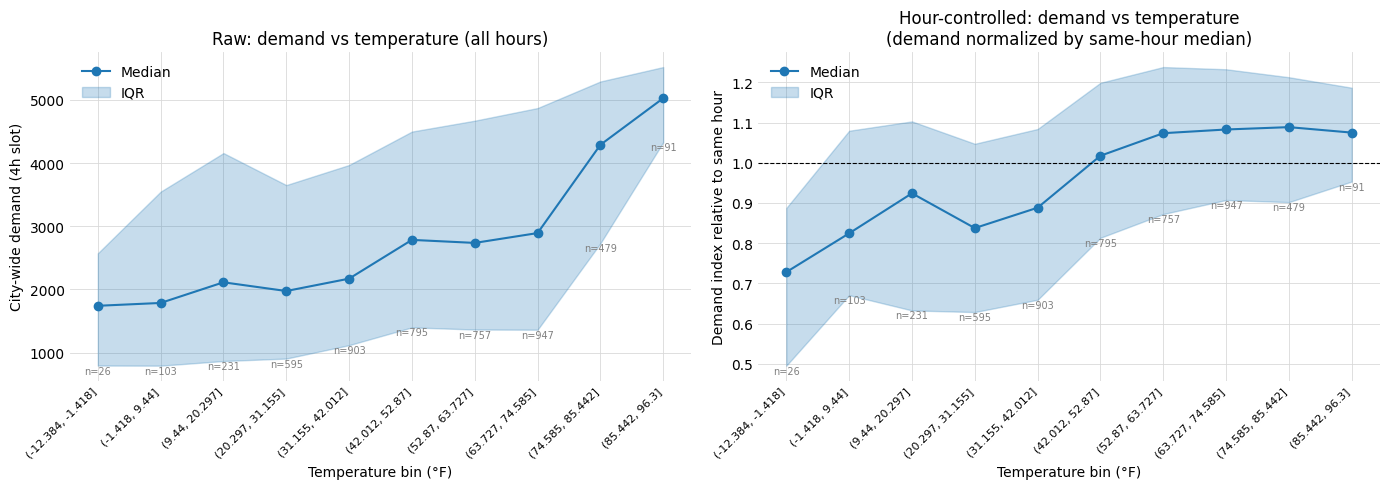

In [31]:
N_BINS = 10
city_4h = city_4h.copy()

# Bin temperature
city_4h["temp_bin"] = pd.cut(city_4h["temp_4h"], bins=N_BINS)

def binned_stats(df, bin_col, val_col):
    g = df.groupby(bin_col, observed=True)[val_col]
    return pd.DataFrame({
        "median": g.median(),
        "q25":    g.quantile(0.25),
        "q75":    g.quantile(0.75),
        "n":      g.count(),
    })

# Raw relationship: demand vs temperature, all hours
stats_all = binned_stats(city_4h, "temp_bin", "demand_count")

# Hour-controlled relationship:
# Normalize demand by the typical demand at the same hour of day.
# This keeps all hours but reduces the time-of-day confound.
city_4h["hour_median_demand"] = city_4h.groupby("hour")["demand_count"].transform("median")
city_4h["demand_index"] = city_4h["demand_count"] / city_4h["hour_median_demand"]

stats_hour_controlled = binned_stats(city_4h, "temp_bin", "demand_index")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_specs = [
    (
        axes[0],
        stats_all,
        "Raw: demand vs temperature (all hours)",
        "City-wide demand (4h slot)"
    ),
    (
        axes[1],
        stats_hour_controlled,
        "Hour-controlled: demand vs temperature\n(demand normalized by same-hour median)",
        "Demand index relative to same hour"
    ),
]

for ax, stats, title, ylabel in plot_specs:
    xs = range(len(stats))

    ax.plot(xs, stats["median"], marker="o", color="tab:blue", label="Median")
    ax.fill_between(
        xs,
        stats["q25"],
        stats["q75"],
        alpha=0.25,
        color="tab:blue",
        label="IQR"
    )

    ax.set_xticks(xs)
    ax.set_xticklabels(
        [str(b) for b in stats.index],
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.set_xlabel("Temperature bin (°F)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0)
    ax.set_axisbelow(True)
    ax.grid(color="0.85", linewidth=0.6)

    # Annotate n per bin
    for x, n in zip(xs, stats["n"]):
        ax.text(
            x,
            stats["q25"].iloc[x],
            f"n={n}",
            ha="center",
            va="top",
            fontsize=7,
            color="grey"
        )

# Reference line for normalized demand
axes[1].axhline(1, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

**2.5b Demand vs precipitation (rain)**

Same hour-of-day confound applies: rain peaks in the afternoon when demand is already high.
Fix: compare rainy vs dry slots **at the same hour of day**, so for each hour we compare
the average demand on rainy vs dry slots. The ratio shows the pure rain lift.

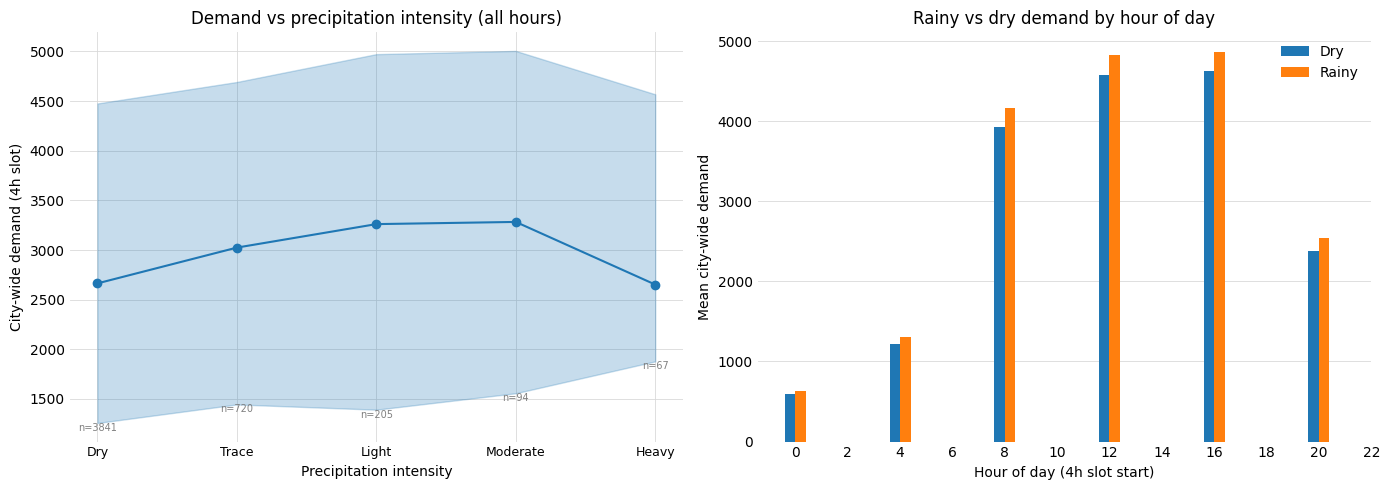

Mean rain demand lift across all hours: +6.1%
is_rainy     Dry   Rainy  rain_lift_%
hour                                 
0          593.5   629.9          6.1
4         1212.8  1301.9          7.3
8         3932.2  4160.7          5.8
12        4579.4  4820.3          5.3
16        4627.8  4866.0          5.1
20        2380.4  2547.0          7.0


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: binned rain intensity vs demand (raw)
precip_bins = pd.cut(city_4h["precip_4h"], bins=[-0.001, 0, 0.05, 0.15, 0.3, np.inf],
                     labels=["Dry", "Trace", "Light", "Moderate", "Heavy"])
city_4h["precip_bin"] = precip_bins
stats_precip = binned_stats(city_4h, "precip_bin", "demand_count")
xs = range(len(stats_precip))
axes[0].plot(xs, stats_precip["median"], marker="o", color="tab:blue")
axes[0].fill_between(xs, stats_precip["q25"], stats_precip["q75"], alpha=0.25, color="tab:blue")
axes[0].set_xticks(xs); axes[0].set_xticklabels(stats_precip.index, fontsize=9)
axes[0].set_xlabel("Precipitation intensity"); axes[0].set_ylabel("City-wide demand (4h slot)")
axes[0].set_title("Demand vs precipitation intensity (all hours)")
for x, n in zip(xs, stats_precip["n"]):
    axes[0].text(x, stats_precip["q25"].iloc[x], f"n={n}", ha="center", va="top", fontsize=7, color="grey")

# Right: rainy vs dry per hour (hour-controlled comparison)
pivot_rain = (city_4h.groupby(["hour", "is_rainy"])["demand_count"]
                .mean().unstack("is_rainy").rename(columns={False: "Dry", True: "Rainy"}))
pivot_rain["rain_lift_%"] = (pivot_rain["Rainy"] / pivot_rain["Dry"] - 1) * 100

ax2 = axes[1]
ax2.bar(pivot_rain.index - 0.2, pivot_rain["Dry"],   width=0.4, label="Dry",   color="tab:blue")
ax2.bar(pivot_rain.index + 0.2, pivot_rain["Rainy"], width=0.4, label="Rainy", color="tab:orange")
ax2.set_xticks(range(0, 24, 2)); ax2.set_xlabel("Hour of day (4h slot start)")
ax2.set_ylabel("Mean city-wide demand"); ax2.set_title("Rainy vs dry demand by hour of day")
ax2.legend(frameon=False)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0)
    ax.set_axisbelow(True)
axes[0].grid(color="0.85", linewidth=0.6)
axes[1].grid(axis="y", color="0.85", linewidth=0.6)

plt.tight_layout(); plt.show()

# Summary: average rain lift across all hours
mean_lift = pivot_rain["rain_lift_%"].mean()
print(f"Mean rain demand lift across all hours: {mean_lift:+.1f}%")
print(pivot_rain[["Dry","Rainy","rain_lift_%"]].round(1).to_string())

**2.5c Demand vs snowfall (winter months only)**

Snow events are sparse outside Nov–Mar, restricting to winter prevents near-zero-count bins from
dominating the comparison. Same hour-controlled approach as precipitation.

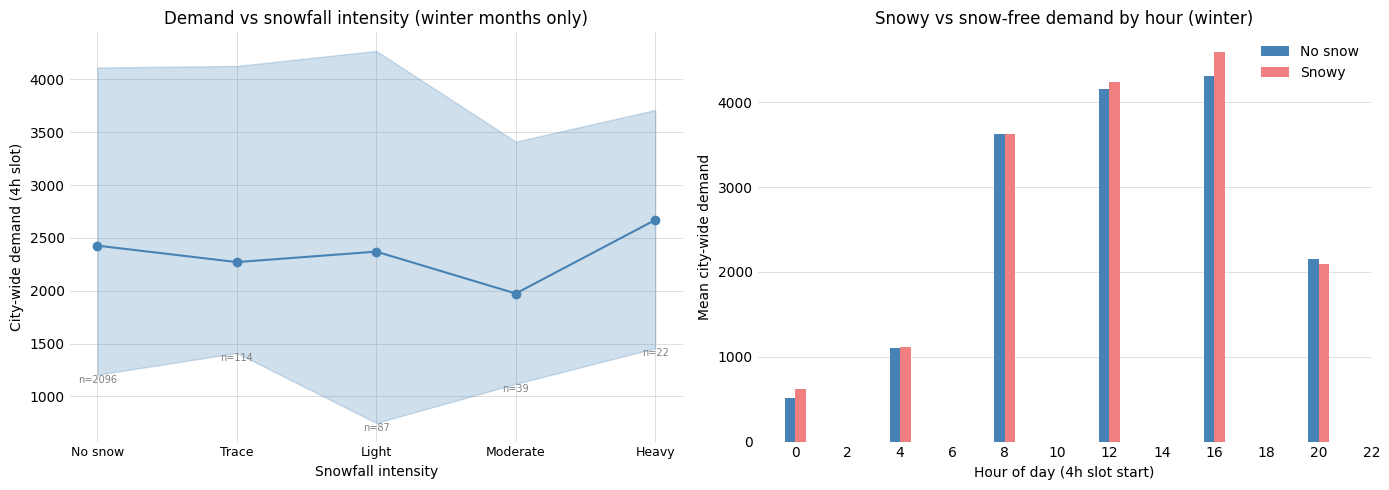

Mean snow demand lift across winter hours: +4.4%


In [35]:
winter = city_4h[city_4h["is_winter"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: binned snow intensity vs demand
snow_bins = pd.cut(winter["snow_4h"], bins=[-0.001, 0, 0.1, 0.3, 0.7, np.inf],
                   labels=["No snow", "Trace", "Light", "Moderate", "Heavy"])
winter["snow_bin"] = snow_bins
stats_snow = binned_stats(winter, "snow_bin", "demand_count")
xs = range(len(stats_snow))
axes[0].plot(xs, stats_snow["median"], marker="o", color="steelblue")
axes[0].fill_between(xs, stats_snow["q25"], stats_snow["q75"], alpha=0.25, color="steelblue")
axes[0].set_xticks(xs); axes[0].set_xticklabels(stats_snow.index, fontsize=9)
axes[0].set_xlabel("Snowfall intensity"); axes[0].set_ylabel("City-wide demand (4h slot)")
axes[0].set_title("Demand vs snowfall intensity (winter months only)")
for x, n in zip(xs, stats_snow["n"]):
    axes[0].text(x, stats_snow["q25"].iloc[x], f"n={n}", ha="center", va="top", fontsize=7, color="grey")

# Right: snowy vs no-snow per hour (hour-controlled)
pivot_snow = (winter.groupby(["hour", "is_snowy"])["demand_count"]
                .mean().unstack("is_snowy").rename(columns={False: "No snow", True: "Snowy"}))
pivot_snow["snow_lift_%"] = (pivot_snow["Snowy"] / pivot_snow["No snow"] - 1) * 100

ax2 = axes[1]
ax2.bar(pivot_snow.index - 0.2, pivot_snow["No snow"], width=0.4, label="No snow", color="steelblue")
ax2.bar(pivot_snow.index + 0.2, pivot_snow["Snowy"],   width=0.4, label="Snowy",   color="lightcoral")
ax2.set_xticks(range(0, 24, 2)); ax2.set_xlabel("Hour of day (4h slot start)")
ax2.set_ylabel("Mean city-wide demand"); ax2.set_title("Snowy vs snow-free demand by hour (winter)")
ax2.legend(frameon=False)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0)
    ax.set_axisbelow(True)
axes[0].grid(color="0.85", linewidth=0.6)
axes[1].grid(axis="y", color="0.85", linewidth=0.6)

plt.tight_layout(); plt.show()

mean_snow_lift = pivot_snow["snow_lift_%"].mean()
print(f"Mean snow demand lift across winter hours: {mean_snow_lift:+.1f}%")

### 2.6 Spatial Variation in Trip Characteristics

For each Community Area, selected per-area trip characteristics are computed and visualised:

- mean trip distance
- mean trip duration
- mean trip total
- mean speed
- mean price per mile
- median idle time
- number of distinct companies operating in the area
- share of digital payments
- mean tip rate

2.2 counts pickups, 2.6 describes what those pickups produce. Two areas can show similar demand volumes but differ substantially in trip economics, payment behaviour, speed and idle time. These differences are relevant for fleet sizing, positioning and revenue expectations.

**2.6 Setup compute per-CA trip characteristics**

In [36]:
# Load only the columns needed 
_cols = ["pickup_community_area", "trip_miles", "trip_seconds", "trip_total",
         "fare", "tips", "payment_type", "company", "avg_speed_mph",
         "price_per_mile"]
trips = pd.read_parquet(PROCESSED / "df_trips_full.parquet", columns=_cols)
trips = trips.dropna(subset=["pickup_community_area"])

DIGITAL_PAYMENTS = {"Credit Card", "Mobile"}
trips["is_digital"] = trips["payment_type"].isin(DIGITAL_PAYMENTS)
trips["tip_rate"]   = (trips["tips"] / trips["fare"]).where(trips["fare"].fillna(0) > 0)
trips["trip_mins"]  = trips["trip_seconds"] / 60

ca_chars = trips.groupby("pickup_community_area", observed=True).agg(
    n_trips            = ("trip_miles",    "size"),
    mean_trip_miles    = ("trip_miles",    "mean"),
    mean_trip_mins     = ("trip_mins",     "mean"),
    mean_trip_total    = ("trip_total",    "mean"),
    mean_speed_mph     = ("avg_speed_mph", "mean"),
    mean_price_per_mile= ("price_per_mile","mean"),
    digital_share      = ("is_digital",    "mean"),
    mean_tip_rate      = ("tip_rate",      "mean"),
    n_companies        = ("company",       "nunique"),
).reset_index()

# Normalise CA key ("32.0" → "32") to match the GeoJSON key
ca_chars["pickup_community_area"] = _norm(ca_chars["pickup_community_area"].astype(str))

del trips   # free memory

idle = pd.read_parquet(PROCESSED / "idle_per_trip.parquet",
                       columns=["pickup_community_area", "idle_seconds"])
idle = idle.dropna(subset=["pickup_community_area"])
idle["pickup_community_area"] = _norm(idle["pickup_community_area"].astype(str))
ca_idle = (idle.groupby("pickup_community_area")["idle_seconds"]
               .median().rename("median_idle_mins").reset_index())
ca_idle["median_idle_mins"] /= 60
del idle

ca_chars = ca_chars.merge(ca_idle, on="pickup_community_area", how="left")
print(f"Trip characteristics computed for {len(ca_chars)} community areas")
print(ca_chars.describe().T[["mean", "min", "max"]].round(2))


Trip characteristics computed for 77 community areas
                              mean        min        max
n_trips              186667.831169     1816.0  3258078.0
mean_trip_miles           7.767404   2.045949  14.246521
mean_trip_mins           22.699559   7.038334  34.747358
mean_trip_total          26.720877   9.759725   54.52272
mean_speed_mph           22.182858  12.630129  35.583106
mean_price_per_mile       14.37277   4.846143  91.574641
digital_share             0.194516   0.005887   0.792769
mean_tip_rate             0.042231   0.002327   0.190317
n_companies              31.324675       15.0       44.0
median_idle_mins         21.038961       15.0       90.0


**2.6a Multi-panel choropleth**

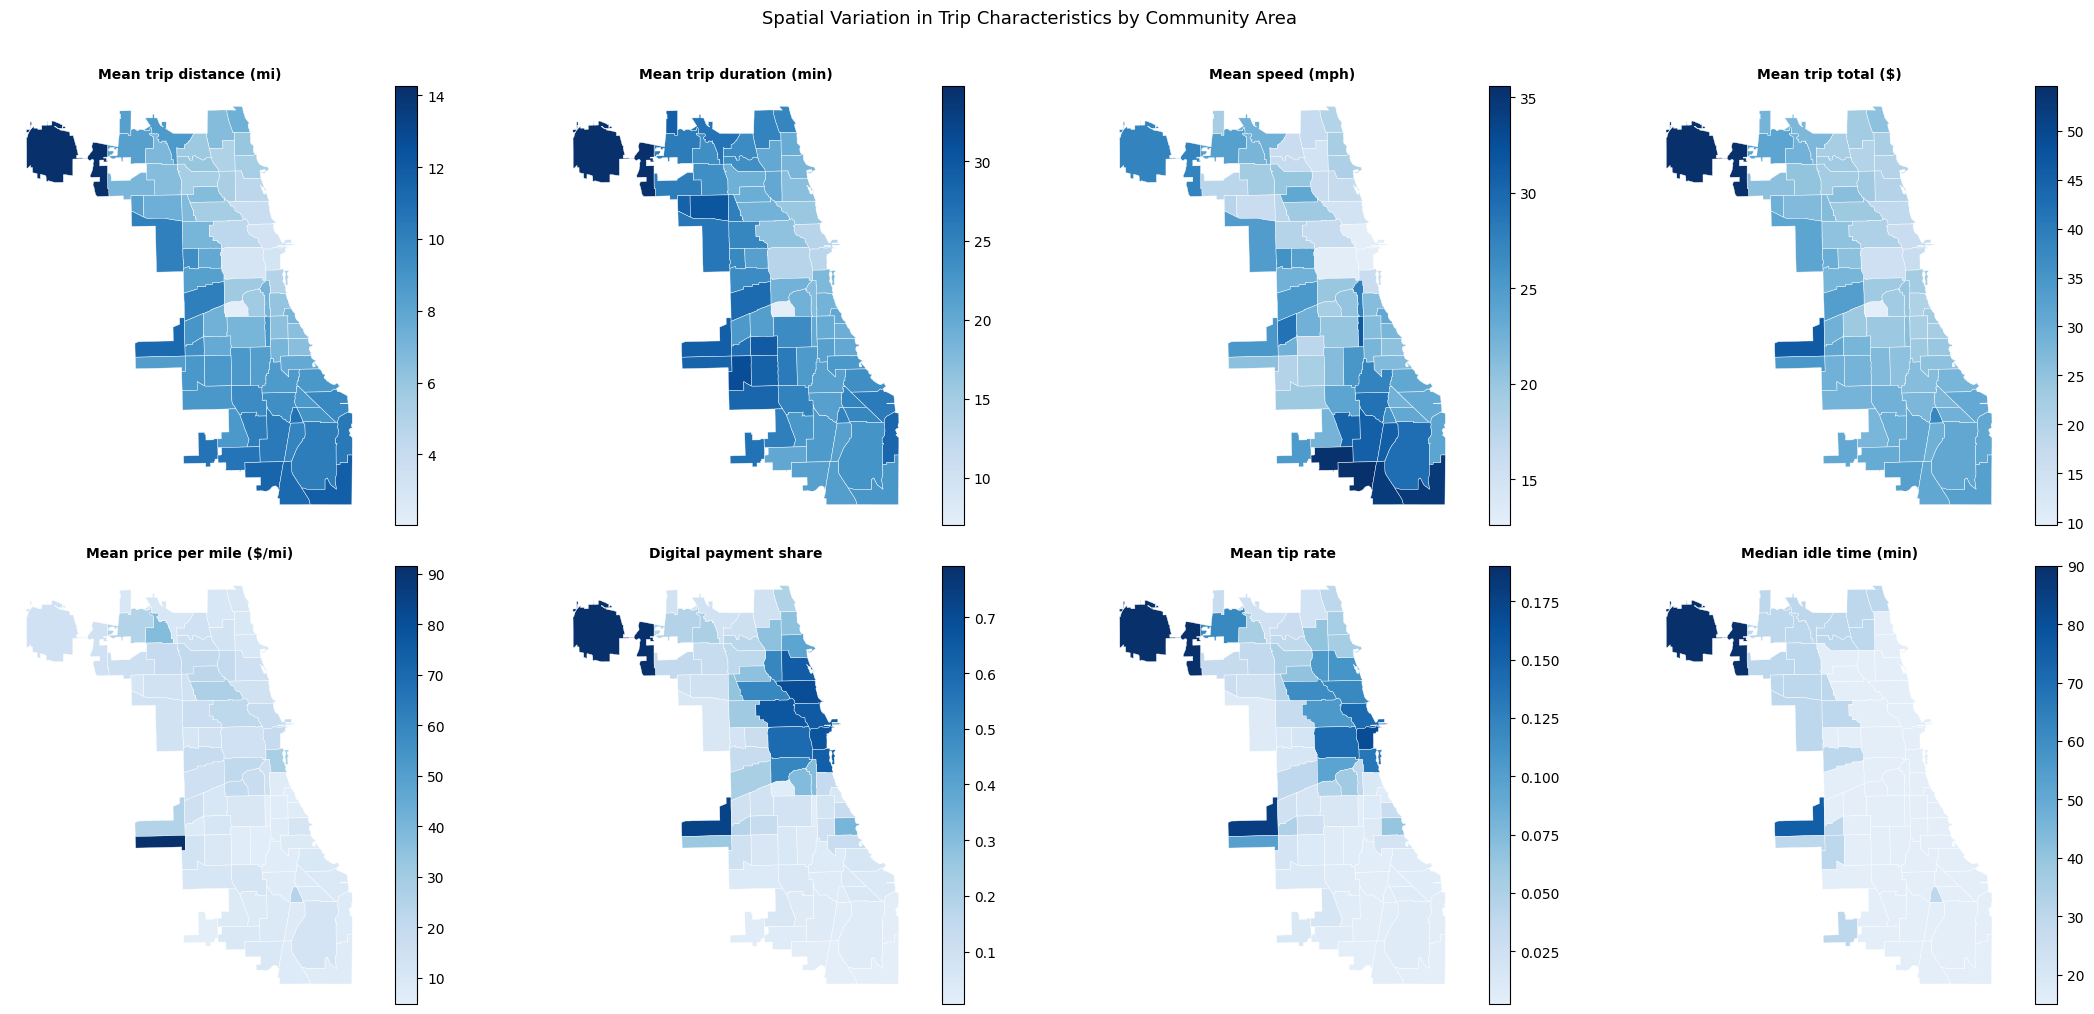

In [65]:
metric_panels = [
    ("mean_trip_miles",     "Mean trip distance (mi)",      BLUES_DARK),
    ("mean_trip_mins",      "Mean trip duration (min)",     BLUES_DARK),
    ("mean_speed_mph",      "Mean speed (mph)",             BLUES_DARK),
    ("mean_trip_total",     "Mean trip total ($)",          BLUES_DARK),
    ("mean_price_per_mile", "Mean price per mile ($/mi)",   BLUES_DARK),
    ("digital_share",       "Digital payment share",        BLUES_DARK),
    ("mean_tip_rate",       "Mean tip rate",                BLUES_DARK),
    ("median_idle_mins",    "Median idle time (min)",       BLUES_DARK),
]

# depends on `gdf` from the 2.2b Community Area choropleth cell. Run that first if this prints the fallback message below.
if "gdf" in dir():
    gdf_chars = gdf[["_key", "geometry"]].merge(
        ca_chars, left_on="_key", right_on="pickup_community_area", how="left"
    )

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    for ax, (col, title, cmap) in zip(axes.ravel(), metric_panels):
        gdf_chars.plot(
            column=col, ax=ax, cmap=cmap, legend=True,
            missing_kwds={"color": "lightgrey", "label": "No data"},
            edgecolor="white", linewidth=0.3,
        )
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_axis_off()

    fig.suptitle("Spatial Variation in Trip Characteristics by Community Area",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("gdf not available, run the Community Area choropleth cell in 2.2b first.")


**2.6b Ranked highlights: which areas stand out?**

The choropleths show spatial structure, bar charts below show which Community Areas sit at the
extremes of each metric. This is useful for fleet operators deciding where to position vehicles.

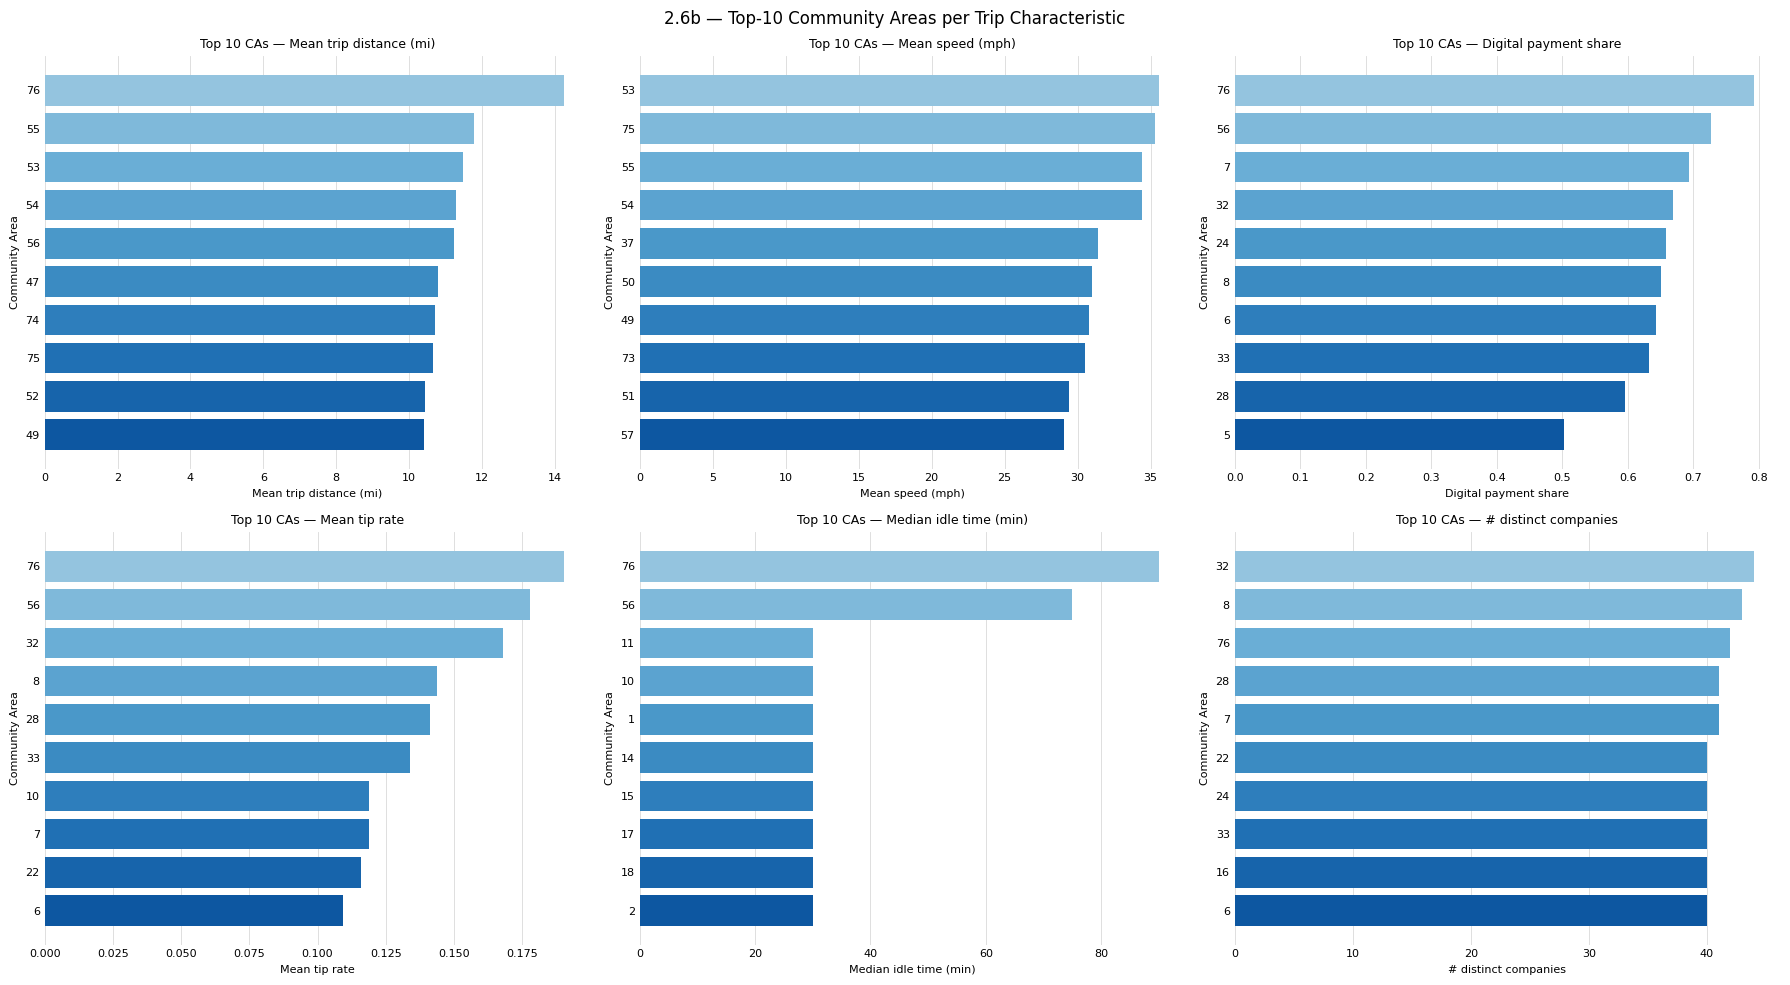


Summary: Top-5 CAs per metric
------------------------------------------------------------

Mean trip distance (mi):
CA  mean_trip_miles
76        14.246521
55        11.782675
53        11.476191
54        11.277612
56        11.219584

Mean speed (mph):
CA  mean_speed_mph
53       35.583106
75       35.302285
55       34.437575
54       34.404339
37       31.432111

Digital payment share:
CA  digital_share
76       0.792769
56       0.726729
 7       0.693353
32       0.668545
24       0.658485

Mean tip rate:
CA  mean_tip_rate
76       0.190317
56       0.178021
32        0.16805
 8       0.143752
28       0.141362

Median idle time (min):
CA  median_idle_mins
76              90.0
56              75.0
 1              30.0
10              30.0
11              30.0

# distinct companies:
CA  n_companies
32           44
 8           43
76           42
28           41
 7           41


In [67]:
TOP_N = 10

highlight_metrics = [
    ("mean_trip_miles",     "Mean trip distance (mi)",    "Blues"),
    ("mean_speed_mph",      "Mean speed (mph)",           "Blues"),
    ("digital_share",       "Digital payment share",      "Blues"),
    ("mean_tip_rate",       "Mean tip rate",              "Blues"),
    ("median_idle_mins",    "Median idle time (min)",     "Blues"),
    ("n_companies",         "# distinct companies",       "Blues"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, title, cmap) in zip(axes.ravel(), highlight_metrics):
    sub = ca_chars[["pickup_community_area", col]].dropna().sort_values(col, ascending=False)
    top = sub.head(TOP_N)
    colors = plt.colormaps[cmap](np.linspace(0.4, 0.85, TOP_N))[::-1]
    ax.barh(top["pickup_community_area"][::-1].astype(str),
            top[col][::-1], color=colors)
    ax.set_title(f"Top {TOP_N} CAs — {title}", fontsize=9)
    ax.set_xlabel(title, fontsize=8)
    ax.set_ylabel("Community Area", fontsize=8)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which="major", length=0, labelsize=8)
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="0.85", linewidth=0.6)

fig.suptitle("2.6b — Top-10 Community Areas per Trip Characteristic", fontsize=12)
plt.tight_layout()
plt.show()

# Print concise summary table (top-5 per metric side by side)
print("\nSummary: Top-5 CAs per metric")
print("-" * 60)
for col, title, _ in highlight_metrics:
    top5 = ca_chars.nlargest(5, col)[["pickup_community_area", col]].reset_index(drop=True)
    top5.columns = ["CA", col]
    print(f"\n{title}:")
    print(top5.to_string(index=False))

### 2.7 Resolution Sensitivity

This section answers the part of the task that asks explicitly to *"show how these patterns vary in different spatio-temporal resolution (census tract vs. varying hexagon diameter and/or temporal bin sizes)"*.

**One distinction up front.** Not every pattern reacts to resolution the same way. Trip-attribute *distributions* (length, price, duration) are essentially resolution-invariant at city level, a trip's length does not change because space is binned differently. What genuinely changes with resolution is (i) the **demand count** per unit and its sparsity, and (ii) the **spatial distribution** of per-area aggregates. This subsection therefore focuses on demand counts and spatial concentration.

**Why spatial is weighted more than temporal.** Spatial aggregation is a structural choice. Different grids (hexagon diameters, administrative areas) have different shapes, sizes and data coverage. Temporal aggregation is a smoothing operation: variance falls with the bin width but the daily cycle keeps its shape. The spatial sweep is therefore the substantive one, the temporal sweep is kept short.

Three blocks follow: **A** spatial sweep (incl. census tract), **B** temporal sweep, **C** GMM hotspots vs grid. The closing block gives the recommended resolution.

**Data dependency:** this section re-aggregates from the trip-level export `df_trips_full.parquet`. Sparsity per (cell x time bucket) cannot be read off the time-collapsed per-cell totals saved for the choropleths, so the trip-level frame is required (the same export that 2.6 already loads). The zero-rate is computed in closed form (`1 - observed / (cells x buckets)`) so the expensive full zero-fill grid is never materialised, which keeps even r8 x 1h tractable.

In [46]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = pathlib.Path("../processed")

# trip-level frame (cell ids r4-r8 + community area + census tract + timestamp + trip chars)
trips = pd.read_parquet(
    PROCESSED / "df_trips_full.parquet",
    columns=["h3_r4", "h3_r6", "h3_r8", "pickup_community_area", "pickup_census_tract",
             "trip_start_timestamp", "pickup_centroid_latitude", "pickup_centroid_longitude"]
)
FREQ = {"time_1h": "h", "time_4h": "4h", "time_8h": "8h", "time_1d": "D"}


def gini(values):
    """Gini coefficient of a 1-D array of non-negative values (0 = equal, ->1 = concentrated)."""
    x = np.sort(np.asarray(values, dtype="float64"))
    n = x.size
    if n == 0 or x.sum() == 0:
        return np.nan
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n


def resolution_stats(trips, spatial_col, time_col):
    """Descriptive sparsity + concentration for one (spatial, temporal) resolution.
    Zero-rate is closed-form (no zero-fill materialised)."""
    t = trips.dropna(subset=[spatial_col])
    bucket = t["trip_start_timestamp"].dt.floor(FREQ[time_col])

    obs = t.groupby([spatial_col, bucket], observed=True).size()           # observed (cell,bucket) counts
    n_cells = int(t[spatial_col].nunique())
    n_buckets = len(pd.date_range(bucket.min(), bucket.max(), freq=FREQ[time_col]))
    zero_rate = 1 - len(obs) / (n_cells * n_buckets)

    per_cell = t.groupby(spatial_col, observed=True).size().sort_values(ascending=False)
    top10 = per_cell.head(max(1, int(0.10 * n_cells))).sum() / per_cell.sum()

    return {"spatial": spatial_col, "temporal": time_col, "n_cells": n_cells,
            "n_buckets": n_buckets, "zero_rate": zero_rate,
            "median_demand": float(obs.median()), "p99_demand": float(obs.quantile(0.99)),
            "gini_per_cell": gini(per_cell.values), "top10pct_share": top10,
            "coverage": len(t) / len(trips)}


#### 2.7a Spatial sweep at fixed 4-hour bins

H3 r4 (coarse) -> r6 -> r8 (fine), plus Community Area and Census Tract, all at 4-hour buckets. The table reports the number of cells, the closed-form zero-rate, median and 99th-percentile demand, the Gini of per-cell demand, the share held by the busiest 10% of cells, and the trip coverage of each spatial key.

**Census tract is included as the task names it explicitly, but with two caveats.** First, `pickup_census_tract` is missing for ~55% of trips (1.3), so its `coverage` is far below 1 and its absolute demand is understated. Second, the missingness is not random: Chicago suppresses the tract precisely when few trips occur there, so it is correlated with low demand and cannot be rescaled by `1/coverage` without distorting the spatial distribution. Census tract is therefore reported for completeness and **not** used as a primary unit, consistent with 1.3.

In [47]:
spatial_res = pd.DataFrame([
    resolution_stats(trips, sp, "time_4h")
    for sp in ["h3_r4", "h3_r6", "h3_r8", "pickup_community_area", "pickup_census_tract"]
])
spatial_res.round(3)


,spatial,temporal,n_cells,n_buckets,zero_rate,median_demand,p99_demand,gini_per_cell,top10pct_share,coverage
0,h3_r4,time_4h,4,4927,0.018,88.0,4788.40,0.629,0.777,1.000
1,h3_r6,time_4h,27,4927,0.126,16.0,2302.14,0.810,0.675,1.000
2,h3_r8,time_4h,475,4927,0.820,6.0,484.00,0.947,0.941,1.000
3,pickup_community_area,time_4h,77,4927,0.173,6.0,984.00,0.841,0.802,0.999
4,pickup_census_tract,time_4h,607,4927,0.947,9.0,480.82,0.976,0.995,0.456


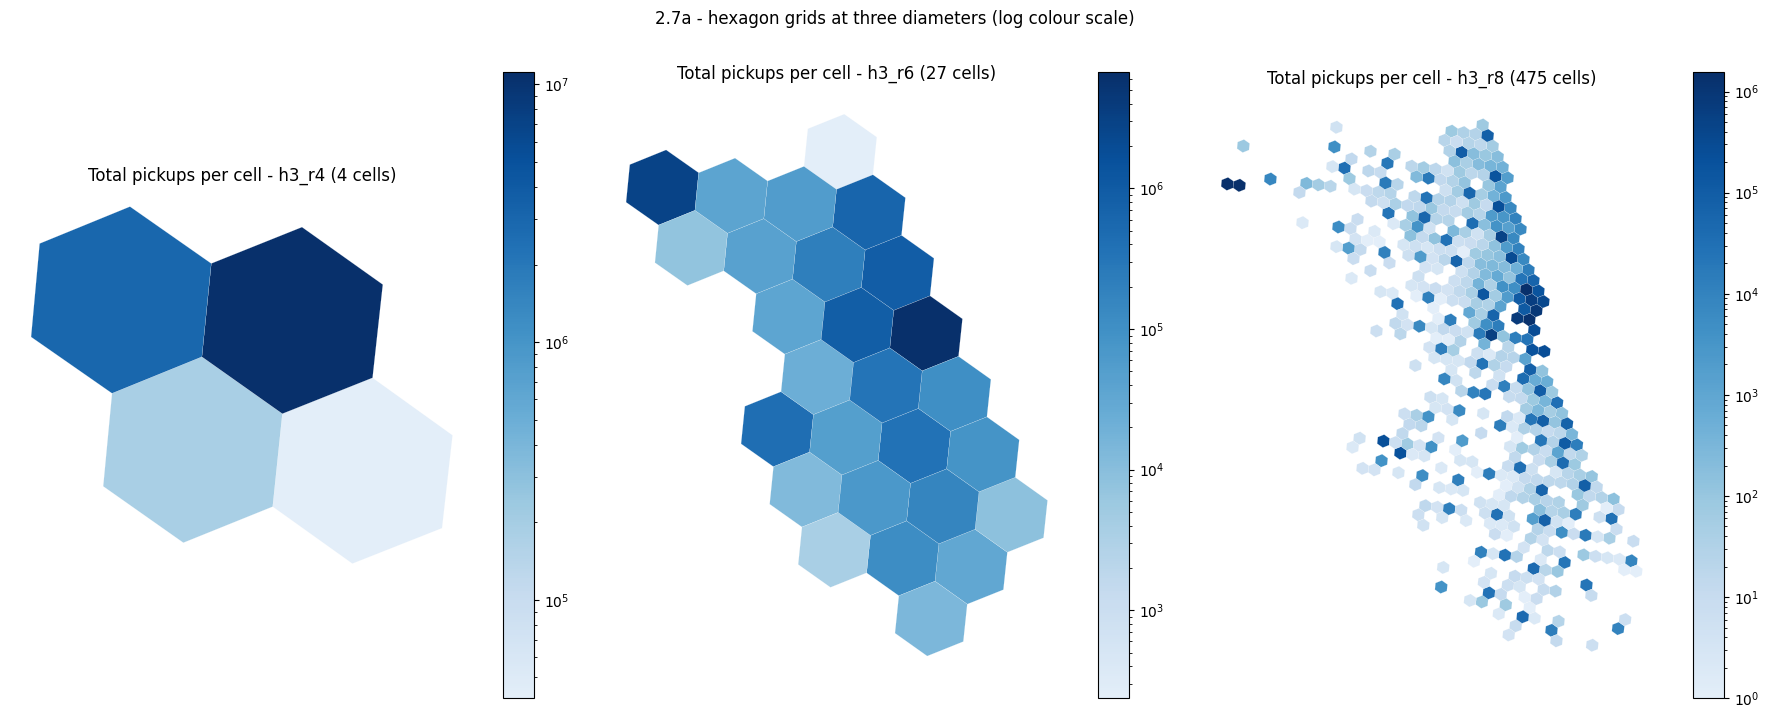

In [58]:
# Choropleth small-multiples: total pickups per cell at r4 / r6 / r8 (hexagon grids, no GeoJSON needed)
import h3
import geopandas as gpd
from shapely.geometry import Polygon
from matplotlib.colors import LogNorm


def h3_poly(cell):
    return Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])   # h3 v4


fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, res in zip(axes, ["h3_r4", "h3_r6", "h3_r8"]):
    tot = trips.groupby(res, observed=True).size().rename("n_trips").reset_index()
    tot["geometry"] = tot[res].apply(h3_poly)
    gdf = gpd.GeoDataFrame(tot, geometry="geometry", crs="EPSG:4326")
    gdf.plot(column="n_trips", cmap=BLUES_DARK, legend=True, linewidth=0.1, edgecolor="white",
             norm=LogNorm(vmin=max(1, tot["n_trips"].min()), vmax=tot["n_trips"].max()), ax=ax)
    ax.set_title(f"Total pickups per cell - {res} ({len(tot)} cells)")
    ax.set_axis_off()
plt.suptitle("2.7a - hexagon grids at three diameters (log colour scale)", y=1.02)
plt.tight_layout(); plt.show()

As the hexagon shrinks the grid explodes and demand fragments: r4 = **4 cells** (zero-rate 1.8%, Gini 0.63), r6 = 27 cells (12.6%, Gini 0.81), r8 = **475 cells, 82.0% of (cell x 4h) buckets empty**, Gini 0.95, with the busiest 10% of cells holding 94% of demand. Concrete reasons: at r4 the whole Loop, Near North and the lakefront collapse into one or two cells (no operational detail); at r8 a single demand centre such as O'Hare is split across several cells, so its total is diluted and the per-cell series becomes noisy. Community Area (77 cells, Gini 0.84) sits close to r6. Census tract is the extreme with **607 cells, 94.7% empty, Gini 0.98**, and only 46% trip coverage, confirming it is unusable as a primary unit.

#### 2.7b Temporal sweep at fixed H3 r6

The spatial unit is held at r6 and the time bucket widened from 1h to 4h, 8h and 1d. Because this is a smoothing operation, the expectation is monotone: zero-rate falls and median demand rises with the bin width, while the daily-cycle shape (already shown at 1h vs 4h in 2.1) is preserved, only flattened.

In [50]:
temporal_res = pd.DataFrame([
    resolution_stats(trips, "h3_r6", tc)
    for tc in ["time_1h", "time_4h", "time_8h", "time_1d"]
])
temporal_res.round(3)

,spatial,temporal,n_cells,n_buckets,zero_rate,median_demand,p99_demand,gini_per_cell,top10pct_share,coverage
0,h3_r6,time_1h,27,19705,0.268,6.0,597.00,0.81,0.675,1.0
1,h3_r6,time_4h,27,4927,0.126,16.0,2302.14,0.81,0.675,1.0
2,h3_r6,time_8h,27,2464,0.078,29.0,4142.91,0.81,0.675,1.0
3,h3_r6,time_1d,27,822,0.040,91.0,9908.50,0.81,0.675,1.0


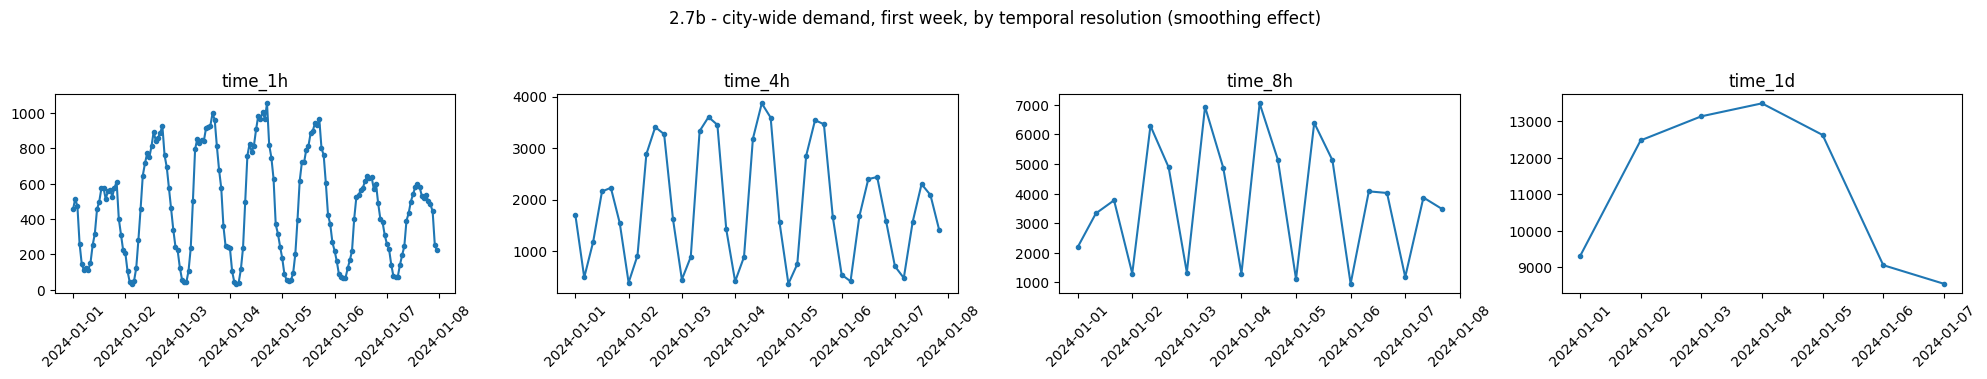

In [51]:
# City-level demand over one representative week at the four temporal resolutions
fig, axes = plt.subplots(1, 4, figsize=(20, 3.6))
for ax, tc in zip(axes, ["time_1h", "time_4h", "time_8h", "time_1d"]):
    s = trips.groupby(trips["trip_start_timestamp"].dt.floor(FREQ[tc]), observed=True).size()
    week = s[(s.index >= s.index.min()) & (s.index < s.index.min() + pd.Timedelta(days=7))]
    ax.plot(week.index, week.values, marker="o", ms=3)
    ax.set_title(tc); ax.tick_params(axis="x", rotation=45)
plt.suptitle("2.7b - city-wide demand, first week, by temporal resolution (smoothing effect)", y=1.04)
plt.tight_layout(); plt.show()

From 1h to 1d the zero-rate falls **26.8% -> 12.6% -> 7.8% -> 4.0%** and the median demand per bucket rises **6 -> 16 -> 29 -> 91**, while the per-cell Gini stays at **0.81** throughout. Temporal aggregation smooths the counts but does not change the spatial concentration. The 1h view shows the sharp commuting and late-evening peaks, by 1d these are flattened into one point per day and the tactical signal (when to deploy within a day) is gone. 4h keeps enough intra-day structure for shift planning while roughly halving the zero-rate of 1h, which is the practical compromise also chosen in Task 1.

**Note on idle time.** The task lists *average idle time between trips* among the patterns to study. Idle is a per-taxi quantity (gap between one taxi's consecutive trips), not a per-cell count, so binning space or time finer only re-averages the same values into noisier bins without revealing new structure. Idle is therefore analysed on its natural axes over time in 2.1 and over space (per Community Area) in 2.6, and is deliberately not part of this resolution sweep.

#### 2.7c GMM hotspots vs grid hotspots

The Gaussian-Mixture hotspots from 2.2 are independent of any grid. Overlaying their centres on the top-10 cells of each hexagon resolution shows how grid choice distorts the apparent hotspots: a coarse grid (r4) merges separate centres into one cell, a fine grid (r8) splits a single centre across many cells. A small GMM is refitted here on a coordinate sample so the block is self-contained and mirrors 2.2.

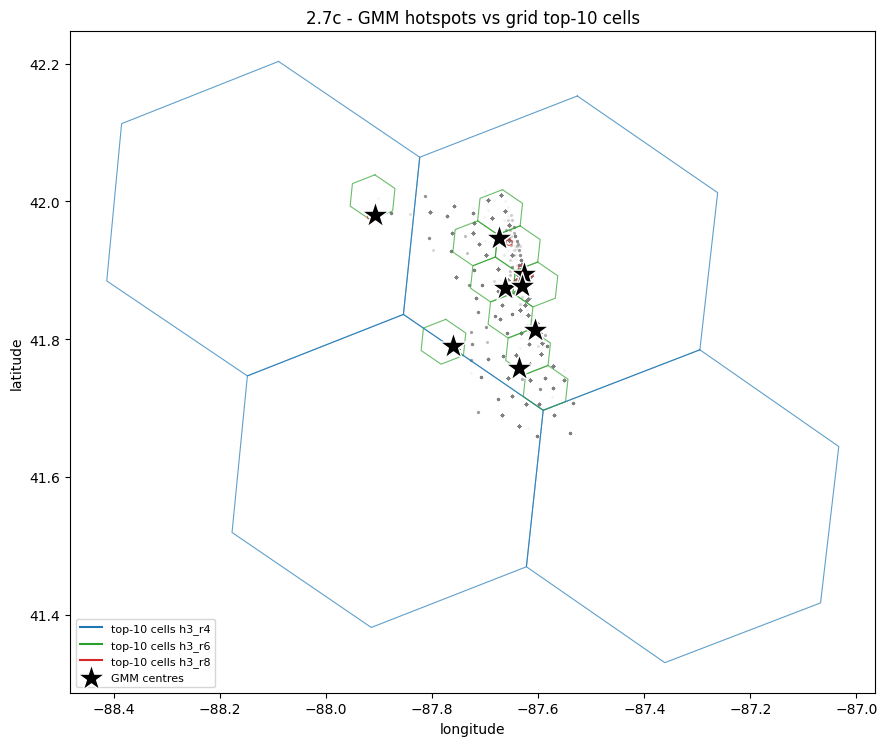

In [53]:
from sklearn.mixture import GaussianMixture

coords = trips[["pickup_centroid_latitude", "pickup_centroid_longitude"]].dropna()
samp = coords.sample(min(50_000, len(coords)), random_state=42)
gmm = GaussianMixture(n_components=8, covariance_type="full", random_state=42).fit(samp.values)
centres = gmm.means_

fig, ax = plt.subplots(figsize=(9, 10))
ax.scatter(samp["pickup_centroid_longitude"], samp["pickup_centroid_latitude"],
           s=2, alpha=0.05, color="grey")
for res, col in [("h3_r4", "#1f77b4"), ("h3_r6", "#2ca02c"), ("h3_r8", "#d62728")]:
    top = trips.groupby(res, observed=True).size().sort_values(ascending=False).head(10).index
    for c in top:
        b = h3.cell_to_boundary(c)
        ax.plot([lon for lat, lon in b] + [b[0][1]],
                [lat for lat, lon in b] + [b[0][0]], color=col, lw=0.8, alpha=0.7)
    ax.plot([], [], color=col, label=f"top-10 cells {res}")
ax.scatter(centres[:, 1], centres[:, 0], marker="*", s=420, c="black",
           edgecolor="white", zorder=5, label="GMM centres")
ax.set(title="2.7c - GMM hotspots vs grid top-10 cells", xlabel="longitude", ylabel="latitude")
ax.set_aspect(1.3); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()


The GMM centres land on the genuine demand cores (Loop, O'Hare, Midway, Near North). The r4 top-10 cells are too blunt to separate Loop from Near North, the r8 top-10 cells cluster several around one airport, over-counting it. r6 aligns most closely with the GMM centres, which is one more argument for r6 as the working resolution.

#### Recommendation

Across the three blocks, **H3 r6 x 4h** is the resolution that best balances spatial detail against sparsity. It is fine enough to separate the real demand cores (2.7c) yet not so fine that the demand panel becomes dominated by empty buckets (2.7a/b). Coarser hexagons (r4) and daily bins lose the operational signal, finer hexagons (r8) and hourly bins inflate the zeros. Community Area remains useful for interpretation and for the OD/per-area views (2.4, 2.6) because it is human-readable, and census tract is documented but unsuitable as a primary unit. This is the resolution carried into the predictive modelling in Task 3.

### 2.8 Summary and Implications

This section consolidates the descriptive findings (2.1-2.7) into the three decision layers the client (a car manufacturer building an electric ride-hailing fleet) actually faces. The framing follows the strategic / tactical / operational split from 1.1.

#### Strategic - where to enter the market first

Demand is highly concentrated: a small number of areas (the Loop and Near North downtown core, and the two airports O'Hare and Midway) account for a large share of all pickups, and they stay dominant across hours and weeks (2.2, 2.3, 2.7a). The GMM hotspots (2.2, 2.7c) confirm these as genuine spatial cores rather than grid artefacts.

*Implication:* a phased market entry should start with the downtown core plus the airport corridors. These offer the highest, most reliable demand density and are therefore the safest place to commit the first vehicles and the first charging capital. Outer neighbourhoods are thinner and more volatile and are better served later.

#### Tactical - when and how many vehicles, where

Demand follows strong and predictable cycles: a weekday commuting profile distinct from the weekend leisure profile, clear intra-day peaks, and a seasonal/monthly component (2.1, 2.3). Weather modulates this on top of the calendar, where warmer weather and rain both lift demand (rain ≈ +6% at matched hours), while snows a slight lift (4.4%). This effect is real even after controlling for time of day (2.5).

*Implication:* fleet size should be planned per shift and per area, not as a flat number. The heatmap matrix (2.3) is effectively a deployment schedule: which cells need vehicles at which hours. Weather-aware buffers are worthwhile because the weather signal is genuine, not a time-of-day artefact.

#### Operational - repositioning, idle time, charging

The origin-destination flows are asymmetric (2.4): some corridors carry far more traffic one way than the other, so vehicles accumulate at destinations and must be repositioned back empty. Idle time is high in low-demand hours and in peripheral areas (2.1, 2.6), marking local over-supply. Per-area trip characteristics differ sharply (2.6): the core produces many short, high-throughput trips, the airports fewer but long, high-value ones.

*Implication:* repositioning should target the high-asymmetry corridors, and charging is best scheduled into the high-idle windows and locations, where vehicles already sit unused. The short-trip core favours high vehicle turnover, the long-trip airport runs favour range and charge planning. Two different operating regimes within one city.

#### Possible reasons for the observed patterns

Consolidated causal reading: the weekday morning/evening peaks reflect commuting; the downtown concentration reflects business and nightlife density; the airport hotspots reflect inbound/outbound travel with long, high-fare trips; the weekend shift reflects leisure travel later in the day; the weather lift reflects substitution away from walking and transit in poor conditions. These are hypotheses supported by the data, consistent with the urban-mobility literature, and would be confirmed with point-of-interest data (a documented next step).

#### Limitations and bridge to Task 3

- **Weather** is from a single city-centre station (1.5) and fine spatial weather differences within Chicago are not captured, which is acceptable at 4h granularity but a limitation for finer work.
- **Census tract** is structurally incomplete (~55% suppressed, demand-correlated), so any tract-level absolute demand is understated and not rescalable (2.7a).
- **Sample period** limits the seasonal coverage as rare high-demand events are under-represented.

**Bridge to Task 3.** The resolution analysis (2.7) selects **H3 r6 x 4h** as the modelling unit, and the descriptive structure here, strong calendar cycles, a genuine weather effect, stable spatial cores, defines the feature space (calendar, weather, location) for the predictive models that follow.